## Cell 0 — Install dependencies (run first!)

In [2]:
# ============================================================
# CELL 0 — Install / verify dependencies
# Run this cell FIRST, then Kernel → Restart & Run All
# ============================================================
import subprocess, sys

pkgs = ["netcdf4", "h5netcdf", "xlrd", "openpyxl"]
for pkg in pkgs:
    r = subprocess.run([sys.executable, "-m", "pip", "install", pkg],
                       capture_output=True, text=True)
    status = "OK" if r.returncode == 0 else "FAILED"
    print(f"  [{status}] {pkg}")
print("\nAll packages checked. Now do: Kernel → Restart → Run All Cells")


  [OK] netcdf4
  [OK] h5netcdf
  [OK] xlrd
  [OK] openpyxl

All packages checked. Now do: Kernel → Restart → Run All Cells


## Cell 1 — Imports

In [4]:
# ============================================================
# CELL 1 — Imports
# ============================================================
import pandas as pd
import numpy as np
import os, glob, zipfile
import geopandas as gpd
import xarray as xr
from shapely.geometry import Point, MultiPoint
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, accuracy_score,
                             precision_recall_curve)
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, LSTM, Conv1D, MaxPooling1D,
                                     Flatten, Bidirectional, Multiply, Permute,
                                     RepeatVector, Lambda)
from tensorflow.keras import backend as K
import xgboost as xgb

print("All imports OK")
print(f"TensorFlow: {tf.__version__}")
print(f"XGBoost:    {xgb.__version__}")


All imports OK
TensorFlow: 2.21.0
XGBoost:    3.2.0


## Cell 2 — Check working directory

In [6]:
# ============================================================
# CELL 2 — Check working directory
# ============================================================
print("=" * 65)
print("NOTEBOOK IS RUNNING FROM:")
print(" ", os.getcwd())
print("=" * 65)
print()
print("Your data files must be in THAT folder (or a subfolder of it).")
print("List of files/folders found there:")
for item in sorted(os.listdir(".")):
    kind = "[DIR] " if os.path.isdir(item) else "[FILE]"
    print(f"  {kind} {item}")


NOTEBOOK IS RUNNING FROM:
  C:\Users\BIT\Desktop\Lightining

Your data files must be in THAT folder (or a subfolder of it).
List of files/folders found there:
  [DIR]  .ipynb_checkpoints
  [FILE] 104ff1ed84426a2928cecddfecf6c896 . zip
  [FILE] 1a5b348018d44da0c7f419775fca96e3 . zip
  [FILE] 72a219acaf5320b59dd4631304544795 . zip
  [FILE] All District lightning data2017_2022 (2).xls
  [DIR]  Cleaned_Data
  [FILE] Jharkhand all District Weather (2).xls
  [FILE] Lightning.ipynb
  [FILE] Lightning_Fixed.ipynb
  [FILE] Lightning_Fixed_v3.ipynb
  [DIR]  Paper_Results
  [DIR]  jharkhand_shapefile
  [FILE] newhybrid (1).ipynb
  [DIR]  temp_cape


## Cell 3 — Config & path verification

In [8]:
# ============================================================
# CELL 3 — Config & path verification
# ============================================================
# FOLDER = "."  means files are in the SAME folder as this notebook
# If your files are inside a sub-folder, change "." to that folder name
FOLDER       = "."           # <── change only if files are in a sub-folder
RESULTS_DIR  = "Paper_Results"
CLEANED_DIR  = "Cleaned_Data"
for d in [RESULTS_DIR, CLEANED_DIR]:
    os.makedirs(d, exist_ok=True)

LIS_FILE      = os.path.join(FOLDER, "All District lightning data2017_2022 (2).xls")
MET_FILE      = os.path.join(FOLDER, "Jharkhand all District Weather (2).xls")
CAPE_ZIPS     = [
    os.path.join(FOLDER, "1a5b348018d44da0c7f419775fca96e3 . zip"),
    os.path.join(FOLDER, "72a219acaf5320b59dd4631304544795 . zip"),
    os.path.join(FOLDER, "104ff1ed84426a2928cecddfecf6c896 . zip"),
]
SHAPEFILE_DIR = os.path.join(FOLDER, "jharkhand_shapefile")

print("[PATH CHECK]\n")
all_ok = True
for label, path in [("LIS  (lightning)", LIS_FILE),
                     ("MET  (weather)",   MET_FILE),
                     ("Shapefile dir",    SHAPEFILE_DIR)]:
    ok = os.path.exists(path)
    print(f"  [{'OK  ' if ok else 'MISS'}] {label}")
    print(f"         {os.path.abspath(path)}")
    if not ok: all_ok = False

for i, zp in enumerate(CAPE_ZIPS):
    ok = os.path.exists(zp)
    print(f"  [{'OK  ' if ok else 'MISS'}] CAPE zip {i+1}")
    print(f"         {os.path.abspath(zp)}")
    if not ok: all_ok = False

print()
if all_ok:
    print("  ALL FILES FOUND — safe to continue.")
else:
    print("  SOME FILES MISSING.")
    print("  Fix: open Cell 3, change FOLDER to match your sub-folder name.")

# ── District name fix map ──────────────────────────────────────────────────
DISTRICT_FIX_MAP = {
    "Pashchimi Singhbhum": "West Singhbhum",
    "Pashchim Singhbhum":  "West Singhbhum",
    "West Singbhum":       "West Singhbhum",
    "W. Singhbhum":        "West Singhbhum",
    "W Singhbhum":         "West Singhbhum",
    "Chaibasa":            "West Singhbhum",
    "Paschimi Singhbhum":  "West Singhbhum",
    "Purbi Singhbhum":     "East Singhbhum",
    "East Singbhum":       "East Singhbhum",
    "Purba Singhbhum":     "East Singhbhum",
    "Jamshedpur":          "East Singhbhum",
    "Saraikela Kharsawan": "Seraikela-Kharsawan",
    "Seraikela Kharsawan": "Seraikela-Kharsawan",
    "Saraikela":           "Seraikela-Kharsawan",
    "Seraikela":           "Seraikela-Kharsawan",
    "Palamau":  "Palamu",   "Sahebganj": "Sahibganj",
    "Kodarma":  "Koderma",  "Deogarh":   "Deoghar",
    "Pakaur":   "Pakur",
    "Ramgarh District": "Ramgarh", "Latehar District": "Latehar",
    "Ranchi District":  "Ranchi",  "Khunti District":  "Khunti",
}
VALID_DISTRICTS = [
    "Ranchi", "East Singhbhum", "West Singhbhum", "Seraikela-Kharsawan",
    "Dhanbad", "Bokaro", "Hazaribagh", "Ramgarh", "Giridih", "Koderma",
    "Chatra", "Latehar", "Palamu", "Garhwa", "Lohardaga", "Gumla",
    "Simdega", "Khunti", "Godda", "Sahibganj", "Pakur", "Jamtara",
    "Deoghar", "Dumka",
]
def clean_name(name):
    return str(name).strip().replace("  ", " ").title()

print("\nConfig loaded.")


[PATH CHECK]

  [OK  ] LIS  (lightning)
         C:\Users\BIT\Desktop\Lightining\All District lightning data2017_2022 (2).xls
  [OK  ] MET  (weather)
         C:\Users\BIT\Desktop\Lightining\Jharkhand all District Weather (2).xls
  [OK  ] Shapefile dir
         C:\Users\BIT\Desktop\Lightining\jharkhand_shapefile
  [OK  ] CAPE zip 1
         C:\Users\BIT\Desktop\Lightining\1a5b348018d44da0c7f419775fca96e3 . zip
  [OK  ] CAPE zip 2
         C:\Users\BIT\Desktop\Lightining\72a219acaf5320b59dd4631304544795 . zip
  [OK  ] CAPE zip 3
         C:\Users\BIT\Desktop\Lightining\104ff1ed84426a2928cecddfecf6c896 . zip

  ALL FILES FOUND — safe to continue.

Config loaded.


## Cell 4 — Data loading (CAPE + MET + LIS)

In [10]:
# ============================================================
# CELL 4 — Data loading functions (CAPE, MET, LIS)
# ============================================================

def _read_any(path, label):
    """
    Read .xls / .xlsx / .csv robustly.
    Many files exported from Google Earth Engine have a .xls extension
    but are actually CSV — this handles that transparently.
    Returns a clean DataFrame (no Unnamed columns, no blank-name columns).
    """
    ext = os.path.splitext(path)[1].lower()
    print(f"  DEBUG: Reading {label} → {os.path.abspath(path)}")
    df = None

    if ext == ".xls":
        try:
            df = pd.read_excel(path, engine="xlrd")
            print(f"  DEBUG: Read as real Excel (.xls) ✓")
        except Exception as e:
            print(f"  DEBUG: xlrd failed ({e})")
            print(f"  DEBUG: File has .xls extension but is actually CSV — retrying...")
            df = pd.read_csv(path, encoding="utf-8-sig", low_memory=False)
            print(f"  DEBUG: Read as CSV ✓")

    elif ext == ".xlsx":
        df = pd.read_excel(path, engine="openpyxl")
        print(f"  DEBUG: Read as Excel (.xlsx) ✓")

    else:
        df = pd.read_csv(path, encoding="utf-8-sig", low_memory=False)
        print(f"  DEBUG: Read as CSV ✓")

    # ── Strip whitespace from column names ──
    df.columns = df.columns.str.strip()

    # ── Drop unnamed / blank columns (trailing comma artefacts) ──
    before = df.shape[1]
    df = df.loc[:, ~df.columns.str.lower().str.startswith("unnamed")]
    df = df.loc[:, df.columns != ""]
    df = df.loc[:, df.columns.str.strip() != ""]
    dropped = before - df.shape[1]

    print(f"  DEBUG: Shape after cleanup: {df.shape}  (dropped {dropped} unnamed/blank cols)")
    print(f"  DEBUG: Columns: {df.columns.tolist()}")
    return df


# ─────────────────────────────────────────────────────────────────────────────
def process_cape_data():
    print("\n" + "="*60)
    print("[Step 1] Processing CAPE Data...")
    print("="*60)

    extract_base = "temp_cape"
    os.makedirs(extract_base, exist_ok=True)

    found = 0
    for zf in CAPE_ZIPS:
        if os.path.exists(zf):
            print(f"  DEBUG: Extracting → {os.path.basename(zf)}")
            with zipfile.ZipFile(zf, "r") as z:
                z.extractall(extract_base)
            found += 1
        else:
            print(f"  DEBUG: Zip MISSING (skipping) → {zf}")

    nc_files = glob.glob(f"{extract_base}/**/*.nc", recursive=True)
    print(f"  DEBUG: {found}/{len(CAPE_ZIPS)} zips extracted | {len(nc_files)} .nc files found")

    processed = []
    for nc in nc_files:
        print(f"  DEBUG: Trying {os.path.basename(nc)} ...")
        # Try netcdf4 first, fall back to scipy / h5netcdf
        for engine in ["netcdf4", "scipy", "h5netcdf"]:
            try:
                ds  = xr.open_dataset(nc, engine=engine)
                df  = ds.to_dataframe().reset_index().dropna()
                tc  = "valid_time" if "valid_time" in df.columns else "time"
                df["Date"] = pd.to_datetime(df[tc]).dt.tz_localize(None).dt.normalize()
                agg = df.groupby("Date").agg({"cape": "mean"}).reset_index()
                processed.append(agg)
                ds.close()
                print(f"  DEBUG: OK with engine='{engine}' → {len(agg)} daily rows")
                break
            except Exception as e:
                print(f"  DEBUG: engine='{engine}' failed → {e}")

    if not processed:
        print("  WARNING: No CAPE data loaded — continuing without it.")
        return pd.DataFrame()

    out = pd.concat(processed).groupby("Date")["cape"].mean().reset_index()
    out.rename(columns={"cape": "CAPE"}, inplace=True)
    out.to_csv(os.path.join(CLEANED_DIR, "cleaned_cape.csv"), index=False)
    print(f"  DEBUG: CAPE saved → {len(out)} rows")
    return out


# ─────────────────────────────────────────────────────────────────────────────
def clean_met_data():
    print("\n" + "="*60)
    print("[Step 2] Cleaning Weather (MET) Data...")
    print("="*60)

    # locate file
    actual = MET_FILE
    if not os.path.exists(actual):
        print(f"  DEBUG: Expected path not found. Auto-searching...")
        cands = (glob.glob(os.path.join(FOLDER, "**/*Weather*.xls"),  recursive=True) +
                 glob.glob(os.path.join(FOLDER, "**/*Weather*.xlsx"), recursive=True) +
                 glob.glob(os.path.join(FOLDER, "**/*weather*.csv"),  recursive=True))
        print(f"  DEBUG: Candidates found: {cands}")
        if not cands:
            print("  ERROR: MET file not found. Check FOLDER in Cell 3.")
            return pd.DataFrame()
        actual = cands[0]
        print(f"  DEBUG: Using → {actual}")

    try:
        df = _read_any(actual, "MET")
    except Exception as e:
        print(f"  ERROR: Could not read MET file → {e}")
        return pd.DataFrame()

    if df is None or df.empty:
        print("  ERROR: MET file is empty after reading.")
        return pd.DataFrame()

    # fix known typo in data
    df.replace("JH>RKHAND", "Jharkhand", regex=True, inplace=True)

    # ── find Date column ──
    date_col = next((c for c in df.columns if c.lower() == "date"), None)
    if not date_col:
        date_col = next((c for c in df.columns if "date" in c.lower()), None)
    print(f"  DEBUG: date_col = '{date_col}'")
    if not date_col:
        print(f"  ERROR: No date column found. Columns: {df.columns.tolist()}")
        return pd.DataFrame()

    # ── find District column: prefer exact 'District' ──
    if "District" in df.columns:
        dist_col = "District"
    elif "district" in df.columns:
        dist_col = "district"
    else:
        # avoid DISTRICT_L / DISTRICT_LGD — those are GIS codes, not names
        candidates = [c for c in df.columns
                      if "dist" in c.lower()
                      and "leng" not in c.lower()
                      and "lgd"  not in c.lower()
                      and c.upper() != "DISTRICT_L"]
        dist_col = candidates[0] if candidates else None
    print(f"  DEBUG: dist_col = '{dist_col}'")
    if not dist_col:
        print(f"  ERROR: No district column found. Columns: {df.columns.tolist()}")
        return pd.DataFrame()

    df["Date"]     = (pd.to_datetime(df[date_col], dayfirst=True, errors="coerce")
                        .dt.tz_localize(None).dt.normalize())
    df["District"] = df[dist_col].apply(clean_name).replace(DISTRICT_FIX_MAP)

    before = len(df)
    df = df[df["District"].isin(VALID_DISTRICTS)].dropna(subset=["Date", "District"])
    print(f"  DEBUG: Rows after district filter: {len(df)} (was {before})")

    if len(df) == 0:
        # show sample of district values to help diagnose
        raw_sample = df[dist_col].unique()[:20] if dist_col in df.columns else []
        print(f"  ERROR: 0 rows remain after filter!")
        print(f"  DEBUG: Sample raw district values: {raw_sample}")
        print(f"  DEBUG: These must match VALID_DISTRICTS after clean_name().")
        return pd.DataFrame()

    # drop junk columns
    for col in ["system:index","Remarks","Shape_Area","Shape_Leng",
                "State_LGD",".geo","ObjectID","DISTRICT_L"]:
        if col in df.columns:
            df.drop(columns=col, inplace=True)

    print(f"  DEBUG: Final MET shape: {df.shape}")
    print(f"  DEBUG: Districts: {sorted(df['District'].unique())}")
    print(f"  DEBUG: Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
    df.to_csv(os.path.join(CLEANED_DIR, "cleaned_met.csv"), index=False)
    print(f"  DEBUG: MET saved to Cleaned_Data/cleaned_met.csv")
    return df


# ─────────────────────────────────────────────────────────────────────────────
def clean_lis_data():
    print("\n" + "="*60)
    print("[Step 3] Cleaning LIS Lightning Data...")
    print("="*60)

    actual = LIS_FILE
    if not os.path.exists(actual):
        print(f"  DEBUG: Expected path not found. Auto-searching...")
        cands = (glob.glob(os.path.join(FOLDER, "**/*lightning*.xls"),  recursive=True) +
                 glob.glob(os.path.join(FOLDER, "**/*Lightning*.xlsx"), recursive=True) +
                 glob.glob(os.path.join(FOLDER, "**/*Lightning*.csv"),  recursive=True))
        print(f"  DEBUG: Candidates: {cands}")
        if not cands:
            print("  ERROR: LIS file not found. Check FOLDER in Cell 3.")
            return pd.DataFrame()
        actual = cands[0]

    try:
        df = _read_any(actual, "LIS")
    except Exception as e:
        print(f"  ERROR: Could not read LIS file → {e}")
        return pd.DataFrame()

    if df is None or df.empty:
        print("  ERROR: LIS file is empty after reading.")
        return pd.DataFrame()

    # ── find time column ──
    time_col = next((c for c in df.columns if "utc" in c.lower()), None)
    print(f"  DEBUG: time_col = '{time_col}'")
    if not time_col:
        print(f"  ERROR: No UTCTime column. Columns: {df.columns.tolist()}")
        return pd.DataFrame()

    def parse_lis_time(x):
        x = str(x).strip()
        try:
            if "T" in x:
                dp = x.split("T")[0]
                if len(dp.split("-")) == 2:
                    return pd.to_datetime(dp, format="%Y-%j")
            return pd.to_datetime(x, errors="coerce")
        except:
            return pd.to_datetime(x, errors="coerce")

    df["Timestamp"] = df[time_col].apply(parse_lis_time)
    df["Date"]      = pd.to_datetime(df["Timestamp"]).dt.tz_localize(None).dt.normalize()
    null_d = df["Date"].isna().sum()
    print(f"  DEBUG: Date parsing done | null dates: {null_d}/{len(df)}")

    # ── find District column ──
    if "District" in df.columns:
        dist_col = "District"
    else:
        dist_col = next((c for c in df.columns if "dist" in c.lower()), None)
    print(f"  DEBUG: dist_col = '{dist_col}'")
    if not dist_col:
        print(f"  ERROR: No district column. Columns: {df.columns.tolist()}")
        return pd.DataFrame()

    df["District"] = df[dist_col].apply(clean_name).replace(DISTRICT_FIX_MAP)
    before = len(df)
    df = df[df["District"].isin(VALID_DISTRICTS)].dropna(subset=["Date", "District"])
    print(f"  DEBUG: Rows after district filter: {len(df)} (was {before})")

    for col in ["Events", "Radiance", "Latitude", "Longitude"]:
        status = "OK" if col in df.columns else "MISSING"
        print(f"  DEBUG: Column '{col}': {status}")

    print(f"  DEBUG: Final LIS shape: {df.shape}")
    print(f"  DEBUG: Districts: {sorted(df['District'].unique())}")
    print(f"  DEBUG: Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
    df.to_csv(os.path.join(CLEANED_DIR, "cleaned_lis.csv"), index=False)
    print(f"  DEBUG: LIS saved to Cleaned_Data/cleaned_lis.csv")
    return df


# ─────────────────────────────────────────────────────────────────────────────
# Run all 3 loaders here so you see output in THIS cell
print("\n>>> Running data loaders...")
cape_df = process_cape_data()
met_df  = clean_met_data()
lis_df  = clean_lis_data()

print("\n" + "="*60)
print("CELL 4 SUMMARY")
print("="*60)
print(f"  CAPE : {len(cape_df)} rows")
print(f"  MET  : {len(met_df)} rows")
print(f"  LIS  : {len(lis_df)} rows")
if met_df.empty:
    print("\n  ACTION NEEDED: MET is empty — see DEBUG above.")
if lis_df.empty:
    print("\n  ACTION NEEDED: LIS is empty — see DEBUG above.")



>>> Running data loaders...

[Step 1] Processing CAPE Data...
  DEBUG: Extracting → 1a5b348018d44da0c7f419775fca96e3 . zip
  DEBUG: Extracting → 72a219acaf5320b59dd4631304544795 . zip
  DEBUG: Extracting → 104ff1ed84426a2928cecddfecf6c896 . zip
  DEBUG: 3/3 zips extracted | 1 .nc files found
  DEBUG: Trying data_stream-oper_stepType-instant.nc ...
  DEBUG: OK with engine='netcdf4' → 730 daily rows
  DEBUG: CAPE saved → 730 rows

[Step 2] Cleaning Weather (MET) Data...
  DEBUG: Reading MET → C:\Users\BIT\Desktop\Lightining\Jharkhand all District Weather (2).xls
  DEBUG: xlrd failed (Unsupported format, or corrupt file: Expected BOF record; found b'\xef\xbb\xbfsyste')
  DEBUG: File has .xls extension but is actually CSV — retrying...
  DEBUG: Read as CSV ✓
  DEBUG: Shape after cleanup: (146729, 16)  (dropped 1689 unnamed/blank cols)
  DEBUG: Columns: ['system:index', 'DISTRICT_L', 'District', 'ObjectID', 'Pressure_hPa', 'Remarks', 'Rh', 'Rain_mm', 'State', 'Shape_Area', 'Shape_Leng', 'S

In [14]:
# ── DIAGNOSTIC CELL — run this before Cell 6 ──────────────
print("Final dataset shape:", final_df.shape)
print("\nAll columns:")
for col in final_df.columns:
    dtype = final_df[col].dtype
    n_unique = final_df[col].nunique()
    n_null = final_df[col].isna().sum()
    sample = final_df[col].dropna().iloc[0] if len(final_df[col].dropna()) > 0 else "ALL NULL"
    print(f"  {col:<30} dtype={str(dtype):<10} unique={n_unique:<6} nulls={n_null:<6} sample={sample}")

Final dataset shape: (48180, 14)

All columns:
  District                       dtype=object     unique=22     nulls=0      sample=Bokaro
  Pressure_hPa                   dtype=object     unique=48176  nulls=0      sample=981.3259003
  Rh                             dtype=object     unique=48180  nulls=0      sample=73.99839401
  Rain_mm                        dtype=object     unique=34172  nulls=0      sample=0.069227417
  State                          dtype=object     unique=1      nulls=0      sample=Jharkhand
  Temp_C                         dtype=object     unique=48179  nulls=0      sample=18.92698873
  WindSpeed                      dtype=object     unique=48179  nulls=0      sample=1.058112382
  Date                           dtype=datetime64[ns] unique=2190   nulls=0      sample=2017-01-01 00:00:00
  Events                         dtype=float64    unique=461    nulls=0      sample=0.0
  Radiance                       dtype=float64    unique=1235   nulls=0      sample=0.0
  La

## Cell 5 — Spatial analysis & dataset merge


[Step 4] Spatial Risk Analysis...

  District                  | Total Events | Days w/ Lightning
  ------------------------------------------------------------
  West Singhbhum            |        36675 |               900
  Simdega                   |        23232 |               641
  East Singhbhum            |        21094 |               473
  Dumka                     |        19528 |               620
  Gumla                     |        17759 |               604
  Ranchi                    |        16898 |               516
  Giridih                   |        14767 |               407
  Khunti                    |        14731 |               386
  Deoghar                   |        13970 |               212
  Hazaribagh                |        13060 |               411

  DEBUG: Top 5 → ['West Singhbhum', 'Simdega', 'East Singhbhum', 'Dumka', 'Gumla']


C:\Users\BIT\AppData\Local\Temp\ipykernel_5400\1256500932.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5.index, y=top5.values, palette="viridis")


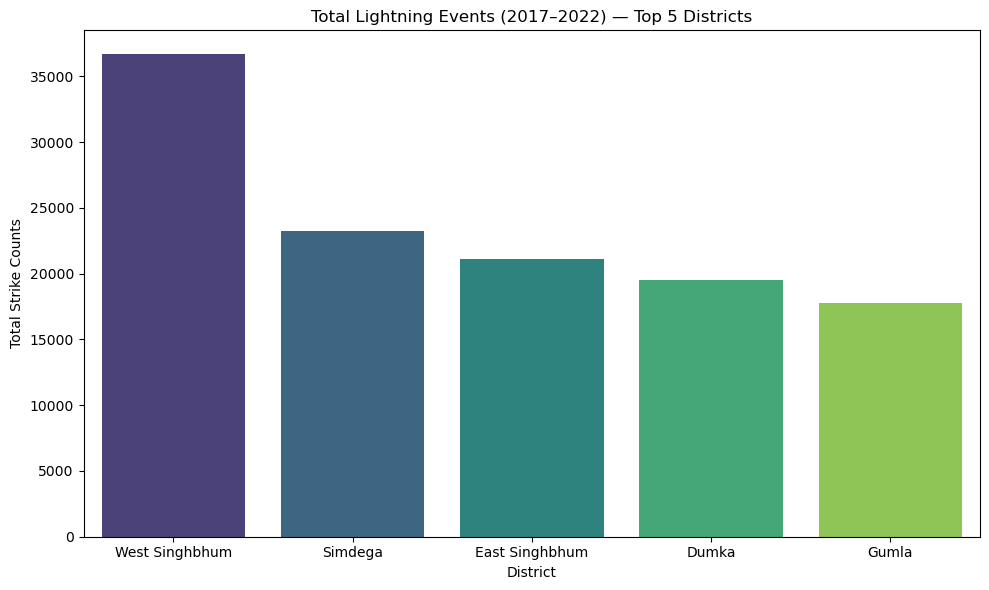

  DEBUG: Bar chart saved.
  DEBUG: Shapefile loaded → .\jharkhand_shapefile\jharkhand_districts (1).shp


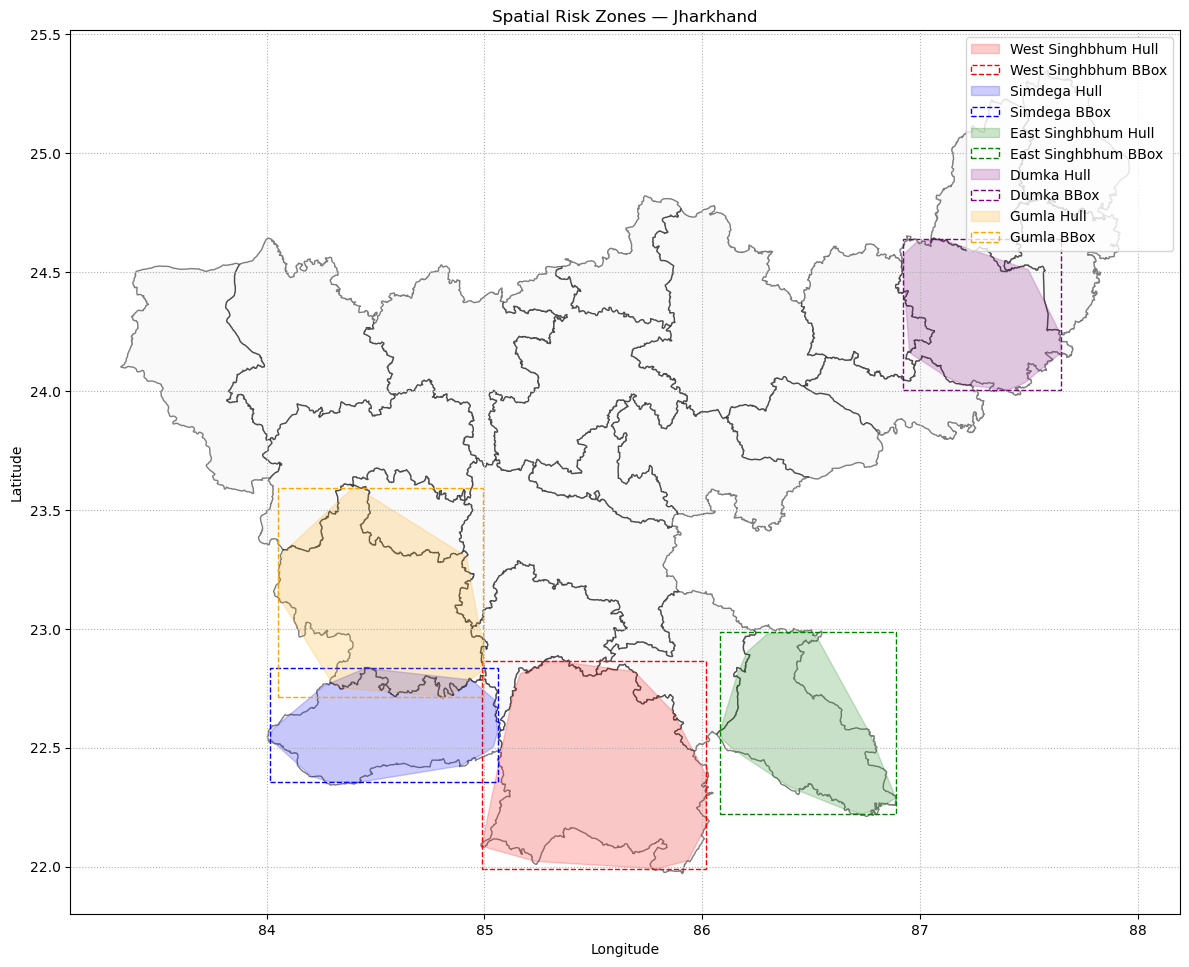

  DEBUG: Spatial map saved.

[Step 5] Merging Datasets...
  DEBUG: LIS aggregated → (1356, 6)
  DEBUG: After MET + LIS merge → (48180, 12)
  DEBUG: After CAPE merge → (48180, 13) | CAPE>0 rows: 14256
  DEBUG: Target — Lightning=1: 1250, Lightning=0: 46930
  DEBUG: Final shape: (48180, 14)
  DEBUG: Final dataset saved → Cleaned_Data\final_merged_prediction_data.csv

CELL 5 SUMMARY
  Top 5 districts : ['West Singhbhum', 'Simdega', 'East Singhbhum', 'Dumka', 'Gumla']
  Final dataset   : (48180, 14)


In [12]:
# ============================================================
# CELL 5 — Spatial analysis & dataset merge
# ============================================================

def perform_spatial_analysis(lis_df):
    print("\n" + "="*60)
    print("[Step 4] Spatial Risk Analysis...")
    print("="*60)

    if lis_df.empty:
        print("  ERROR: LIS dataframe is empty — skipping.")
        return []

    if "Events" not in lis_df.columns:
        print(f"  ERROR: 'Events' column missing. Columns: {lis_df.columns.tolist()}")
        return []

    intensity = lis_df.groupby("District")["Events"].sum().sort_values(ascending=False)
    freq      = lis_df["District"].value_counts()

    print(f"\n  {'District':<25} | {'Total Events':>12} | {'Days w/ Lightning':>17}")
    print("  " + "-"*60)
    for d in intensity.head(10).index:
        print(f"  {d:<25} | {int(intensity[d]):>12} | {int(freq.get(d,0)):>17}")

    top5       = intensity.head(5)
    top5_names = top5.index.tolist()
    print(f"\n  DEBUG: Top 5 → {top5_names}")

    # bar chart
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top5.index, y=top5.values, palette="viridis")
    plt.title("Total Lightning Events (2017–2022) — Top 5 Districts")
    plt.xlabel("District"); plt.ylabel("Total Strike Counts")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "lightning_counts.png"))
    plt.show(); plt.close()
    print("  DEBUG: Bar chart saved.")

    # spatial map
    fig, ax = plt.subplots(figsize=(12, 12))
    shp_path = None
    if os.path.exists(SHAPEFILE_DIR):
        for root, _, files in os.walk(SHAPEFILE_DIR):
            for f in files:
                if f.endswith(".shp"):
                    shp_path = os.path.join(root, f); break

    if shp_path:
        try:
            gpd.read_file(shp_path).plot(ax=ax, color="whitesmoke",
                                          edgecolor="black", alpha=0.5)
            print(f"  DEBUG: Shapefile loaded → {shp_path}")
        except Exception as e:
            print(f"  WARNING: Shapefile error → {e}")
    else:
        print("  WARNING: No .shp file found — map has no base layer.")

    colors = ["red", "blue", "green", "purple", "orange"]
    for i, dist in enumerate(top5_names):
        sub = lis_df[lis_df["District"] == dist]
        if "Latitude" not in sub.columns or "Longitude" not in sub.columns:
            continue
        pts = [Point(xy) for xy in zip(sub.Longitude, sub.Latitude)]
        if len(pts) > 2:
            hull = MultiPoint(pts).convex_hull
            if hull.geom_type == "Polygon":
                x, y = hull.exterior.xy
                ax.fill(x, y, alpha=0.2, fc=colors[i], ec=colors[i],
                        label=f"{dist} Hull")
                minx, miny, maxx, maxy = hull.bounds
                ax.add_patch(plt.Rectangle((minx, miny), maxx-minx, maxy-miny,
                             lw=1, edgecolor=colors[i], facecolor="none",
                             linestyle="--", label=f"{dist} BBox"))

    ax.set_title("Spatial Risk Zones — Jharkhand")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.legend(loc="upper right"); ax.grid(linestyle=":")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "spatial_risk_zones.png"))
    plt.show(); plt.close()
    print("  DEBUG: Spatial map saved.")
    return top5_names


# ─────────────────────────────────────────────────────────────────────────────
def create_final_dataset(met, lis, cape, top5):
    print("\n" + "="*60)
    print("[Step 5] Merging Datasets...")
    print("="*60)

    if met.empty or lis.empty:
        print(f"  ERROR: Cannot merge — MET rows={len(met)}, LIS rows={len(lis)}")
        return pd.DataFrame()

    # ensure timezone-naive dates
    for df in [met, lis]:
        df["Date"] = pd.to_datetime(df["Date"]).dt.tz_localize(None).dt.normalize()
    if not cape.empty:
        cape["Date"] = pd.to_datetime(cape["Date"]).dt.tz_localize(None).dt.normalize()

    # aggregate LIS by Date + District
    agg_map = {c: f for c, f in [("Events","sum"),("Radiance","mean"),
                                   ("Latitude","mean"),("Longitude","mean")]
               if c in lis.columns}
    if not agg_map:
        print(f"  ERROR: None of Events/Radiance/Lat/Lon in LIS. Cols: {lis.columns.tolist()}")
        return pd.DataFrame()

    lis_agg = lis.groupby(["Date", "District"]).agg(agg_map).reset_index()
    print(f"  DEBUG: LIS aggregated → {lis_agg.shape}")

    df = pd.merge(met, lis_agg, on=["Date", "District"], how="left")
    print(f"  DEBUG: After MET + LIS merge → {df.shape}")

    if not cape.empty:
        df = pd.merge(df, cape, on="Date", how="left")
        df["CAPE"] = df["CAPE"].fillna(0)
        print(f"  DEBUG: After CAPE merge → {df.shape} | CAPE>0 rows: {(df['CAPE']>0).sum()}")
    else:
        print("  DEBUG: No CAPE data — skipping CAPE merge.")

    if "Events" not in df.columns:
        print("  ERROR: 'Events' missing after merge — cannot create target variable.")
        return pd.DataFrame()

    df["Lightning_Occurred"] = (df["Events"] > 0).astype(int)
    df["Events"]   = df["Events"].fillna(0)
    if "Radiance" in df.columns:
        df["Radiance"] = df["Radiance"].fillna(0)
    df = df.fillna(0)

    ones  = df["Lightning_Occurred"].sum()
    zeros = (df["Lightning_Occurred"] == 0).sum()
    print(f"  DEBUG: Target — Lightning=1: {ones}, Lightning=0: {zeros}")
    print(f"  DEBUG: Final shape: {df.shape}")

    sp = os.path.join(CLEANED_DIR, "final_merged_prediction_data.csv")
    df.to_csv(sp, index=False)
    print(f"  DEBUG: Final dataset saved → {sp}")
    return df


# ─────────────────────────────────────────────────────────────────────────────
# Run spatial analysis + merge
top5     = perform_spatial_analysis(lis_df)
final_df = create_final_dataset(met_df, lis_df, cape_df, top5)

print("\n" + "="*60)
print("CELL 5 SUMMARY")
print("="*60)
print(f"  Top 5 districts : {top5}")
print(f"  Final dataset   : {final_df.shape}")
if final_df.empty:
    print("\n  ACTION NEEDED: Final dataset empty — check MET/LIS debug above.")


## Cell 6 — Model training (XGBoost + Hybrid LSTM-CNN)

In [ ]:
# ============================================================
# CELL 6 — Model: Hybrid Attention LSTM-CNN + XGBoost
# ============================================================

def build_hybrid_attention_model(input_shape):
    """
    input_shape = (time_steps, n_features)
    FIX: use K.int_shape() — never hardcode RepeatVector(128)
    """
    inp  = Input(shape=input_shape)
    x    = Conv1D(64, 3, activation="relu", padding="same")(inp)
    x    = MaxPooling1D(2)(x)
    x    = Bidirectional(LSTM(64, return_sequences=True))(x)

    # dynamic shape — no hardcoding
    time_steps = K.int_shape(x)[1]
    feat_dim   = K.int_shape(x)[2]
    print(f"  DEBUG: BiLSTM output → time_steps={time_steps}, feat_dim={feat_dim}")

    att = Dense(1, activation="tanh")(x)
    att = Flatten()(att)
    att = Dense(time_steps, activation="softmax")(att)
    att = RepeatVector(feat_dim)(att)
    att = Permute([2, 1])(att)

    sent = Multiply()([x, att])
    sent = Lambda(lambda z: K.sum(z, axis=1))(sent)

    x   = Dense(32, activation="relu")(sent)
    out = Dense(1,  activation="sigmoid")(x)

    model = Model(inp, out)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


def create_sequences(df, features, target_col, look_back=5):
    X_list, y_list = [], []
    for dist in df["District"].unique():
        sub = df[df["District"] == dist].sort_values("Date")
        X   = sub[features].values
        y   = sub[target_col].values
        if len(sub) > look_back:
            for i in range(look_back, len(X)):
                X_list.append(X[i-look_back:i])
                y_list.append(y[i])
    if not X_list:
        return np.array([]), np.array([])
    return np.array(X_list), np.array(y_list)


def run_models(df):
    print("\n" + "="*60)
    print("[Step 6] Training Models...")
    print("="*60)

    if df.empty:
        print("  ERROR: Dataset is empty — cannot train.")
        return

    drop_cols = ["Date","District","Events","Radiance",
                 "Lightning_Occurred","Latitude","Longitude"]
    features  = [c for c in df.select_dtypes(include=[np.number]).columns
                 if c not in drop_cols and not c.lower().startswith("unnamed")]
    print(f"  DEBUG: Feature columns ({len(features)}): {features}")

    if not features:
        print("  ERROR: No numeric feature columns found.")
        return

    X_seq, y_seq = create_sequences(df, features, "Lightning_Occurred", look_back=5)
    print(f"  DEBUG: Sequences — X: {X_seq.shape}, y: {y_seq.shape}")

    if len(X_seq) == 0:
        print("  ERROR: No sequences created. Need >5 rows per district.")
        return
    if len(np.unique(y_seq)) < 2:
        print("  ERROR: Target has only one class. Check merge — lightning events may not have joined.")
        return

    print(f"  DEBUG: Class balance — 0s: {(y_seq==0).sum()}, 1s: {(y_seq==1).sum()}")

    N, T, F = X_seq.shape
    X_flat  = X_seq.reshape(N * T, F)
    X_flat  = RobustScaler().fit_transform(X_flat)
    X_seq   = X_flat.reshape(N, T, F)

    X_train, X_test, y_train, y_test = train_test_split(
        X_seq, y_seq, test_size=0.2, stratify=y_seq, random_state=42)
    print(f"  DEBUG: Train={len(X_train)}, Test={len(X_test)}")

    # ── XGBoost ──────────────────────────────────────────────────────────────
    print("\n  --- XGBoost ---")
    ratio = float(np.sum(y_train==0)) / max(np.sum(y_train==1), 1)
    print(f"  DEBUG: scale_pos_weight = {ratio:.2f}")
    xgb_m = xgb.XGBClassifier(eval_metric="logloss",
                                scale_pos_weight=ratio, random_state=42)
    xgb_m.fit(X_train.reshape(len(X_train), -1), y_train)
    yp = xgb_m.predict(X_test.reshape(len(X_test), -1))
    print(f"  XGBoost Accuracy: {accuracy_score(y_test, yp)*100:.2f}%")
    print(classification_report(y_test, yp))

    # ── Hybrid Attention LSTM-CNN ─────────────────────────────────────────────
    print("  --- Hybrid Attention LSTM-CNN (100 epochs) ---")
    cw      = class_weight.compute_class_weight("balanced",
                classes=np.unique(y_train), y=y_train)
    cw_dict = dict(enumerate(cw))
    print(f"  DEBUG: class weights = {cw_dict}")

    model = build_hybrid_attention_model((T, F))
    model.fit(X_train, y_train, epochs=100, batch_size=32,
              validation_split=0.1, class_weight=cw_dict, verbose=0)
    print("  DEBUG: Training complete.")

    y_prob = model.predict(X_test).flatten()
    pr, rc, th = precision_recall_curve(y_test, y_prob)
    f1s = 2 * (pr * rc) / (pr + rc + 1e-10)
    idx = np.argmax(f1s)
    thr = th[idx] if idx < len(th) else 0.5
    print(f"  DEBUG: Optimal threshold = {thr:.4f}")

    yph = (y_prob > thr).astype(int)
    print(f"  Hybrid Accuracy: {accuracy_score(y_test, yph)*100:.2f}%")
    print(classification_report(y_test, yph))

    # confusion matrix
    cm = confusion_matrix(y_test, yph)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix (threshold={thr:.2f})")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrix.png"))
    plt.show(); plt.close()

    # ROC curve
    try:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_val = roc_auc_score(y_test, y_prob)
        plt.figure()
        plt.plot(fpr, tpr, label=f"Hybrid (AUC={auc_val:.2f})")
        plt.plot([0,1],[0,1],"k--")
        plt.xlabel("FPR"); plt.ylabel("TPR")
        plt.title("ROC Curve"); plt.legend(); plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR, "roc_auc_curve.png"))
        plt.show(); plt.close()
        print(f"  DEBUG: ROC AUC = {auc_val:.4f}")
    except Exception as e:
        print(f"  WARNING: ROC plot failed → {e}")

    # actual vs predicted
    plt.figure(figsize=(12, 4))
    plt.plot(y_test[:100], label="Actual", alpha=0.6)
    plt.plot(yph[:100], label="Predicted", linestyle="--", color="red")
    plt.title("Actual vs Predicted (first 100 samples)")
    plt.legend(); plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "actual_vs_pred.png"))
    plt.show(); plt.close()

    print(f"\n  DEBUG: All plots saved to '{RESULTS_DIR}/'")


# ─────────────────────────────────────────────────────────────────────────────
# Run model training
run_models(final_df)


## Cell 7 — Pipeline summary

In [ ]:
# ============================================================
# CELL 7 — Pipeline summary
# ============================================================
print("\n" + "="*60)
print("PIPELINE COMPLETE")
print("="*60)
print(f"  Cleaned MET data  : {CLEANED_DIR}/cleaned_met.csv")
print(f"  Cleaned LIS data  : {CLEANED_DIR}/cleaned_lis.csv")
print(f"  Cleaned CAPE data : {CLEANED_DIR}/cleaned_cape.csv")
print(f"  Final dataset     : {CLEANED_DIR}/final_merged_prediction_data.csv")
print(f"  All plots/metrics : {RESULTS_DIR}/")
print("="*60)


In [ ]:
# ─────────────────────────────────────────────────────────────
# BETTER MODELS — Replace build_hybrid_attention_model()
# Drop these functions into Cell 6, then call run_all_models()
# ─────────────────────────────────────────────────────────────

from tensorflow.keras.layers import Add

# ── Model 1: 1D ResNet ─────────────────────────────────────
def residual_block(x, filters, kernel_size=3):
    """Skip connection over two Conv1D layers — like ResNet"""
    shortcut = x
    x = Conv1D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = Conv1D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)
    # match dimensions if needed
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding='same')(shortcut)
    x = Add()([x, shortcut])
    x = tf.keras.layers.Activation('relu')(x)
    return x

def build_resnet1d(T, F):
    inp = Input(shape=(T, F))
    x = Conv1D(64, 3, padding='same')(inp)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = residual_block(x, 64)
    x = residual_block(x, 128)
    x = residual_block(x, 128)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.4)(x)
    out = Dense(1, activation='sigmoid')(x)
    model = Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    print(f"  ResNet1D params: {model.count_params():,}")
    return model


# ── Model 2: Temporal Transformer ──────────────────────────
def build_transformer(T, F):
    """Transformer encoder — state of the art for time series"""
    inp = Input(shape=(T, F))
    
    # Project to model dimension
    x = Dense(128)(inp)
    
    # 3 Transformer encoder blocks
    for _ in range(3):
        # Multi-head self-attention
        attn = MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.1)(x, x)
        x    = LayerNormalization()(x + attn)          # residual
        # Feed-forward
        ff   = Dense(256, activation='relu')(x)
        ff   = Dropout(0.1)(ff)
        ff   = Dense(128)(ff)
        x    = LayerNormalization()(x + ff)            # residual
    
    x   = GlobalAveragePooling1D()(x)
    x   = Dense(64, activation='relu')(x)
    x   = Dropout(0.3)(x)
    out = Dense(1, activation='sigmoid')(x)
    
    model = Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    print(f"  Transformer params: {model.count_params():,}")
    return model


# ── Model 3: TCN (Temporal Convolutional Network) ──────────
def tcn_block(x, filters, kernel_size, dilation_rate):
    """Dilated causal conv — captures long range without LSTM"""
    shortcut = x
    x = Conv1D(filters, kernel_size, padding='causal',
               dilation_rate=dilation_rate, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Conv1D(filters, kernel_size, padding='causal',
               dilation_rate=dilation_rate, activation='relu')(x)
    x = BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding='same')(shortcut)
    return Add()([x, shortcut])

def build_tcn(T, F):
    inp = Input(shape=(T, F))
    x = inp
    # Stacked dilated convolutions: 1, 2, 4 → exponentially growing receptive field
    for dilation in [1, 2, 4]:
        x = tcn_block(x, filters=64, kernel_size=3, dilation_rate=dilation)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation='sigmoid')(x)
    model = Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    print(f"  TCN params: {model.count_params():,}")
    return model


# ── Focal Loss — fixes the class imbalance properly ────────
def focal_loss(gamma=2.0, alpha=0.75):
    """
    Penalises easy negatives heavily.
    alpha=0.75 means 75% weight on the minority class (lightning).
    This is WHY your model gets 90% accuracy but 0.06 precision —
    standard BCE just learns to predict 0 always.
    """
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce    = -y_true * tf.math.log(y_pred) - (1-y_true) * tf.math.log(1-y_pred)
        p_t    = y_true * y_pred + (1-y_true) * (1-y_pred)
        alpha_t = y_true * alpha + (1-y_true) * (1-alpha)
        return tf.reduce_mean(alpha_t * tf.pow(1-p_t, gamma) * bce)
    return loss


# ── Run all models and compare ──────────────────────────────
def run_all_models(df):
    print("\n" + "="*60)
    print("Training 4 models — comparing on class-1 F1 & AUC")
    print("="*60)

    # ── reuse your existing sequence builder ──
    drop = ['Date','District','Events','Radiance',
            'Lightning_Occurred','Latitude','Longitude']
    features = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in drop and not c.lower().startswith('unnamed')]
    print(f"  Features ({len(features)}): {features}")

    X, y = create_sequences(df, features, 'Lightning_Occurred', look_back=5)[:2]
    print(f"  Sequences → X:{X.shape}  y:{y.shape}")
    print(f"  Class balance → 0s:{(y==0).sum()}  1s:{(y==1).sum()}")

    if len(X)==0 or len(np.unique(y))<2:
        print("  ERROR: not enough data"); return

    N,T,F = X.shape
    scaler = RobustScaler()
    X = scaler.fit_transform(X.reshape(N*T,F)).reshape(N,T,F)

    X_train,X_test,y_train,y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42)

    cw      = class_weight.compute_class_weight('balanced',
                  classes=np.unique(y_train), y=y_train)
    cw_dict = dict(enumerate(cw))

    cb = [
        tf.keras.callbacks.EarlyStopping(
            patience=8, restore_best_weights=True, monitor='val_auc', mode='max'),
        tf.keras.callbacks.ReduceLROnPlateau(
            patience=4, factor=0.5, monitor='val_auc', mode='max')
    ]

    models_to_train = {
        'XGBoost':     None,
        'ResNet1D':    build_resnet1d(T, F),
        'Transformer': build_transformer(T, F),
        'TCN':         build_tcn(T, F),
    }

    results = {}

    for name, model in models_to_train.items():
        print(f"\n{'─'*50}")
        print(f"  Training: {name}")
        print('─'*50)

        if name == 'XGBoost':
            ratio = float(np.sum(y_train==0)) / max(np.sum(y_train==1),1)
            clf = xgb.XGBClassifier(
                n_estimators=300, max_depth=6, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                scale_pos_weight=ratio, eval_metric='logloss',
                random_state=42)
            clf.fit(X_train.reshape(len(X_train),-1), y_train, verbose=False)
            y_prob = clf.predict_proba(X_test.reshape(len(X_test),-1))[:,1]
        else:
            # Use focal loss for deep models — fixes the imbalance issue
            model.compile(
                optimizer=model.optimizer,
                loss=focal_loss(gamma=2.0, alpha=0.75),
                metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                         tf.keras.metrics.Recall(name='recall')]
            )
            model.fit(X_train, y_train, epochs=80, batch_size=32,
                      validation_split=0.15, class_weight=cw_dict,
                      callbacks=cb, verbose=0)
            y_prob = model.predict(X_test, verbose=0).flatten()

        # optimal threshold via F1
        pr, rc, th = precision_recall_curve(y_test, y_prob)
        f1s = 2*(pr*rc)/(pr+rc+1e-10)
        thr = th[np.argmax(f1s[:-1])] if len(th)>0 else 0.5
        y_pred = (y_prob > thr).astype(int)

        acc = accuracy_score(y_test, y_pred)
        try:
            auc = roc_auc_score(y_test, y_prob)
        except:
            auc = float('nan')

        report = classification_report(y_test, y_pred,
                                       zero_division=0, output_dict=True)
        f1_class1 = report.get('1', {}).get('f1-score', 0)

        print(f"  Accuracy  : {acc*100:.2f}%")
        print(f"  AUC       : {auc:.4f}")
        print(f"  F1 (class-1 / lightning): {f1_class1:.4f}  ← this is the real metric")
        print(classification_report(y_test, y_pred, zero_division=0))

        results[name] = dict(acc=acc, auc=auc, f1_c1=f1_class1,
                             y_prob=y_prob, y_pred=y_pred, thr=thr)

    # ── Summary table ──────────────────────────────────────
    print("\n" + "="*60)
    print(f"  {'Model':<18} {'Accuracy':>10} {'AUC':>8} {'F1 (lightning)':>16}")
    print("  " + "-"*56)
    for name, r in results.items():
        print(f"  {name:<18} {r['acc']*100:>9.2f}%  {r['auc']:>7.4f}  {r['f1_c1']:>15.4f}")
    best = max(results, key=lambda n: results[n]['auc'])
    print(f"\n  Best model: {best}  (AUC={results[best]['auc']:.4f})")

    # ── ROC plot ───────────────────────────────────────────
    plt.figure(figsize=(8, 6))
    for name, r in results.items():
        try:
            fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
            plt.plot(fpr, tpr, lw=2,
                     label=f"{name} (AUC={r['auc']:.3f}, F1={r['f1_c1']:.3f})")
        except: pass
    plt.plot([0,1],[0,1],'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves — all models')
    plt.legend(fontsize=9); plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'roc_comparison.png'), dpi=150)
    plt.show(); plt.close()

    return results


results = run_all_models(final_df)

In [ ]:
!pip install torch

DIAGNOSTIC: checking final_df columns
Shape: (48180, 14)

  District                  dtype=object     unique_vals=22
  Pressure_hPa              dtype=object     unique_vals=48176
  Rh                        dtype=object     unique_vals=48180
  Rain_mm                   dtype=object     unique_vals=34172
  State                     dtype=object     unique_vals=1
  Temp_C                    dtype=object     unique_vals=48179
  WindSpeed                 dtype=object     unique_vals=48179
  Date                      dtype=datetime64[ns] unique_vals=2190
  Events                    dtype=float64    unique_vals=461
  Radiance                  dtype=float64    unique_vals=1235
  Latitude                  dtype=float64    unique_vals=1135
  Longitude                 dtype=float64    unique_vals=1159
  CAPE                      dtype=float32    unique_vals=641
  Lightning_Occurred        dtype=int32      unique_vals=2

FIXING: converting weather columns to numeric
  Pressure_hPa    was object

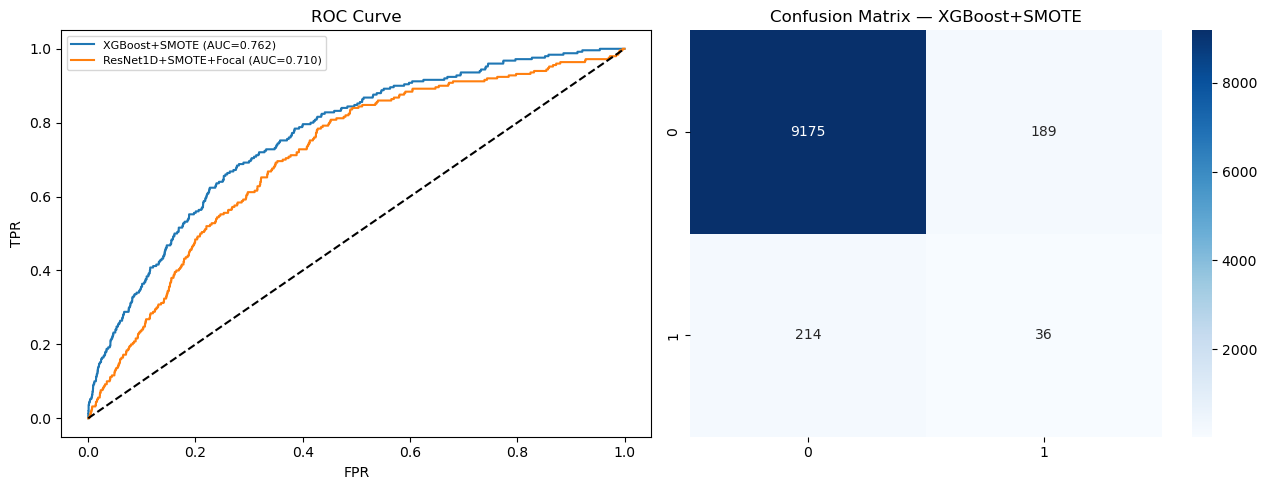


Best model: XGBoost+SMOTE (PR-AUC=0.1066)


In [16]:
# ============================================================
# DIAGNOSTIC + FIX + RETRAIN — all in one cell
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, LSTM, Bidirectional, Dropout,
                                     Conv1D, MaxPooling1D, BatchNormalization,
                                     GlobalAveragePooling1D, Add, Activation)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, accuracy_score, precision_recall_curve,
                             f1_score, average_precision_score)
from sklearn.utils import class_weight
import xgboost as xgb

# ── STEP 1: Diagnose what's actually in final_df ──────────────────────────
print("="*60)
print("DIAGNOSTIC: checking final_df columns")
print("="*60)
print(f"Shape: {final_df.shape}\n")
for col in final_df.columns:
    dtype = final_df[col].dtype
    nun   = final_df[col].nunique()
    print(f"  {col:<25} dtype={str(dtype):<10} unique_vals={nun}")

# ── STEP 2: Force-convert weather columns to numeric ───────────────────────
print("\n" + "="*60)
print("FIXING: converting weather columns to numeric")
print("="*60)
numeric_cols = ['Pressure_hPa', 'Rh', 'Rain_mm', 'Temp_C', 'WindSpeed',
                'CAPE', 'Events', 'Radiance', 'Latitude', 'Longitude']
df = final_df.copy()
for col in numeric_cols:
    if col in df.columns:
        before_dtype = df[col].dtype
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        print(f"  {col:<15} was {str(before_dtype):<8} → now numeric | "
              f"non-zero: {(df[col]!=0).sum()} | mean: {df[col].mean():.3f}")

# ── STEP 3: Pick only features that are real and useful ───────────────────
DESIRED_FEATURES = ['Temp_C', 'Rh', 'Rain_mm', 'Pressure_hPa', 'WindSpeed', 'CAPE']
features = []
print("\nFeature selection:")
for col in DESIRED_FEATURES:
    if col not in df.columns:
        print(f"  [MISS] {col}")
    elif df[col].nunique() <= 1:
        print(f"  [SKIP] {col} — constant/all-zero")
    else:
        print(f"  [OK]   {col} — {df[col].nunique()} unique values")
        features.append(col)
print(f"\nUsing {len(features)} features: {features}")

if len(features) < 2:
    raise ValueError("Still too few features — check MET file column names in cleaned_met.csv")

# ── STEP 4: Build sequences ─────────────────────────────────────────────────
def build_sequences(df, features, target, look_back=5):
    X_list, y_list = [], []
    for dist in df['District'].unique():
        sub = df[df['District']==dist].sort_values('Date').reset_index(drop=True)
        if len(sub) <= look_back: continue
        Xd, yd = sub[features].values.astype(np.float32), sub[target].values
        for i in range(look_back, len(Xd)):
            X_list.append(Xd[i-look_back:i]); y_list.append(yd[i])
    return np.array(X_list, dtype=np.float32), np.array(y_list)

X, y = build_sequences(df, features, 'Lightning_Occurred', look_back=5)
print(f"\nSequences → X:{X.shape}  y:{y.shape}")
print(f"Class balance → 0s:{(y==0).sum()}  1s:{(y==1).sum()}  "
      f"(ratio 1:{(y==0).sum()/(y==1).sum():.1f})")

N, T, F = X.shape
scaler = RobustScaler()
X = scaler.fit_transform(X.reshape(N*T, F)).reshape(N, T, F)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train={len(X_train)}  Test={len(X_test)}")

# ── STEP 5: SMOTE to balance training data ─────────────────────────────────
print("\n" + "="*60)
print("APPLYING SMOTE — generating synthetic lightning samples")
print("="*60)
try:
    from imblearn.combine import SMOTETomek
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "imbalanced-learn"], check=True)
    from imblearn.combine import SMOTETomek

sm = SMOTETomek(random_state=42)
X_tr_flat, y_train_res = sm.fit_resample(X_train.reshape(len(X_train), -1), y_train)
X_train_res = X_tr_flat.reshape(-1, T, F)
print(f"Before SMOTE → 0s:{(y_train==0).sum()}  1s:{(y_train==1).sum()}")
print(f"After  SMOTE → 0s:{(y_train_res==0).sum()}  1s:{(y_train_res==1).sum()}")

# ── STEP 6: Focal loss (also fixes imbalance, used together with SMOTE) ────
def focal_loss(gamma=2.0, alpha=0.75):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
        bce = -y_true*tf.math.log(y_pred) - (1-y_true)*tf.math.log(1-y_pred)
        p_t = y_true*y_pred + (1-y_true)*(1-y_pred)
        alpha_t = y_true*alpha + (1-y_true)*(1-alpha)
        return tf.reduce_mean(alpha_t * tf.pow(1-p_t, gamma) * bce)
    return loss

# ── STEP 7: ResNet1D model ──────────────────────────────────────────────────
def residual_block(x, filters, kernel_size=3):
    shortcut = x
    x = Conv1D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x); x = Activation('relu')(x)
    x = Conv1D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding='same')(shortcut)
    x = Add()([x, shortcut])
    return Activation('relu')(x)

def build_resnet1d(T, F):
    inp = Input(shape=(T, F))
    x = Conv1D(64, 3, padding='same')(inp)
    x = BatchNormalization()(x); x = Activation('relu')(x)
    x = residual_block(x, 64)
    x = residual_block(x, 128)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.4)(x)
    out = Dense(1, activation='sigmoid')(x)
    model = Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                   loss=focal_loss(gamma=2.0, alpha=0.75),
                   metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                            tf.keras.metrics.Recall(name='recall')])
    return model

# ── STEP 8: Train XGBoost on SMOTE data ─────────────────────────────────────
print("\n" + "="*60)
print("TRAINING: XGBoost (on SMOTE-balanced data)")
print("="*60)
xgb_m = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8,
                           eval_metric='logloss', random_state=42)
xgb_m.fit(X_train_res.reshape(len(X_train_res), -1), y_train_res, verbose=False)
xgb_prob = xgb_m.predict_proba(X_test.reshape(len(X_test), -1))[:, 1]

# ── STEP 9: Train ResNet1D on SMOTE data ────────────────────────────────────
print("\n" + "="*60)
print("TRAINING: ResNet1D (SMOTE + focal loss)")
print("="*60)
cb = [tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True,
                                       monitor='val_auc', mode='max'),
      tf.keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5,
                                           monitor='val_auc', mode='max')]
resnet = build_resnet1d(T, F)
resnet.fit(X_train_res, y_train_res, epochs=100, batch_size=32,
           validation_split=0.15, callbacks=cb, verbose=0)
resnet_prob = resnet.predict(X_test, verbose=0).flatten()
print("Training complete.")

# ── STEP 10: Evaluate both with proper imbalanced metrics ──────────────────
def evaluate(name, y_test, y_prob):
    pr, rc, th = precision_recall_curve(y_test, y_prob)
    f1s = 2*(pr*rc)/(pr+rc+1e-10)
    thr = th[np.argmax(f1s[:-1])] if len(th) > 0 else 0.5
    y_pred = (y_prob > thr).astype(int)
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    f1_c1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    print(f"\n[{name}] threshold={thr:.3f}")
    print(f"  Accuracy : {acc*100:.2f}%")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"  PR-AUC   : {pr_auc:.4f}   (more meaningful than ROC-AUC here)")
    print(f"  F1 class1: {f1_c1:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))
    return dict(name=name, acc=acc, auc=auc, pr_auc=pr_auc, f1_c1=f1_c1,
                y_prob=y_prob, y_pred=y_pred, thr=thr)

print("\n" + "="*60)
print("RESULTS")
print("="*60)
r1 = evaluate("XGBoost+SMOTE", y_test, xgb_prob)
r2 = evaluate("ResNet1D+SMOTE+Focal", y_test, resnet_prob)

# ── STEP 11: Summary + plots ────────────────────────────────────────────────
print("\n" + "="*60)
print(f"  {'Model':<22}{'Acc':>8}{'ROC-AUC':>10}{'PR-AUC':>9}{'F1(c1)':>9}")
print("  " + "-"*58)
for r in [r1, r2]:
    print(f"  {r['name']:<22}{r['acc']*100:>7.2f}%{r['auc']:>10.4f}{r['pr_auc']:>9.4f}{r['f1_c1']:>9.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for r in [r1, r2]:
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    axes[0].plot(fpr, tpr, label=f"{r['name']} (AUC={r['auc']:.3f})")
axes[0].plot([0,1],[0,1],'k--'); axes[0].set_title("ROC Curve")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].legend(fontsize=8)

best = max([r1, r2], key=lambda r: r['pr_auc'])
cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title(f"Confusion Matrix — {best['name']}")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "smote_comparison.png"), dpi=150)
plt.show(); plt.close()

print(f"\nBest model: {best['name']} (PR-AUC={best['pr_auc']:.4f})")

In [ ]:
# Check CAPE date coverage
cape_check = final_df[final_df['CAPE'] != 0]
print(f"CAPE has real data for: {cape_check['Date'].min()} to {cape_check['Date'].max()}")
print(f"Full dataset covers:    {final_df['Date'].min()} to {final_df['Date'].max()}")
print(f"\nDays with CAPE: {final_df['Date'][final_df['CAPE']!=0].nunique()}")
print(f"Total days:     {final_df['Date'].nunique()}")

In [ ]:
# Spatial signal: did a neighboring district have lightning yesterday?
neighbor_map = {
    'Ranchi': ['Khunti', 'Ramgarh', 'Lohardaga'],
    'East Singhbhum': ['West Singhbhum', 'Seraikela-Kharsawan'],
    # ... fill in for your top 5 districts based on actual geography
}

df['neighbor_lightning_lag1'] = 0
for dist, neighbors in neighbor_map.items():
    mask = df['District'] == dist
    neighbor_data = df[df['District'].isin(neighbors)].groupby('Date')['Lightning_Occurred'].max()
    df.loc[mask, 'neighbor_lightning_lag1'] = df.loc[mask, 'Date'].map(neighbor_data).shift(1).fillna(0)

In [ ]:
# Change this line:
DESIRED_FEATURES = ['Temp_C', 'Rh', 'Rain_mm', 'Pressure_hPa', 'WindSpeed', 'CAPE']

# To this:
DESIRED_FEATURES = ['Temp_C', 'Rh', 'Rain_mm', 'Pressure_hPa', 'WindSpeed']

In [ ]:
print(f"Before (with bad CAPE): PR-AUC = 0.1066")
print(f"After  (without CAPE):  PR-AUC = {r1['pr_auc']:.4f}")

 DATASET OVERVIEW
Shape: 48,180 rows × 14 columns
Date range: 2017-01-01 to 2022-12-30
Districts: 22

Column summary:
                             dtype  non_null  null_pct  zero_pct  nunique
District                    object     48180       0.0       0.0       22
Pressure_hPa               float64     48180       0.0       0.0    48176
Rh                         float64     48180       0.0       0.0    48180
Rain_mm                    float64     48180       0.0       7.5    34172
State                       object     48180       0.0       0.0        1
Temp_C                     float64     48180       0.0       0.0    48179
WindSpeed                  float64     48180       0.0       0.0    48179
Date                datetime64[ns]     48180       0.0       0.0     2190
Events                     float64     48180       0.0      97.4      461
Radiance                   float64     48180       0.0      97.4     1235
Latitude                   float64     48180       0.0      97.4    

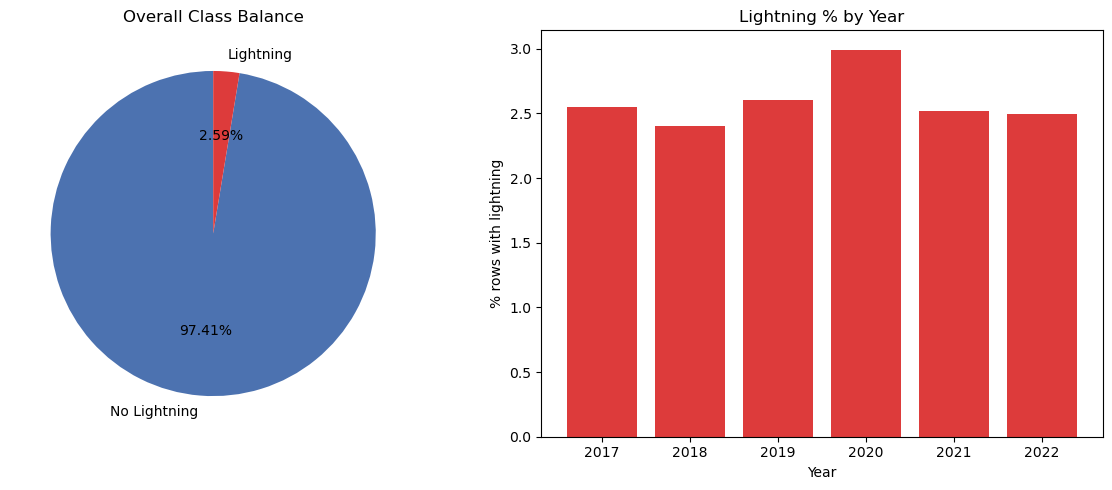


 2. DATA COVERAGE OVER TIME (zero/missing check per feature)


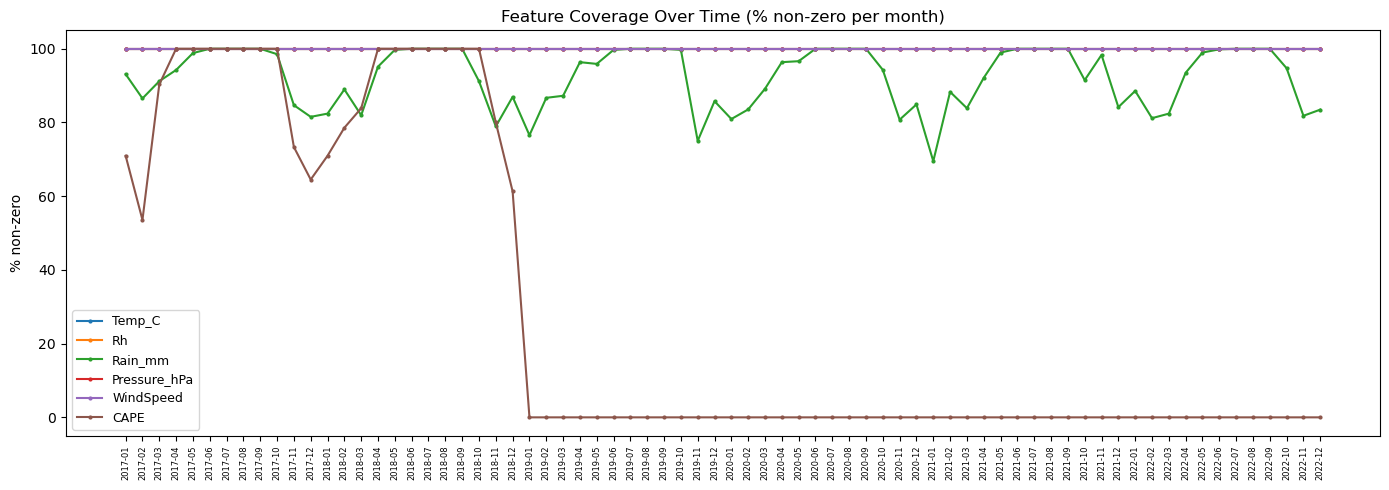

Look for any line that DROPS TO 0 partway through — that's a hidden coverage gap (like CAPE).

 3. FEATURE DISTRIBUTIONS (Lightning vs No Lightning)


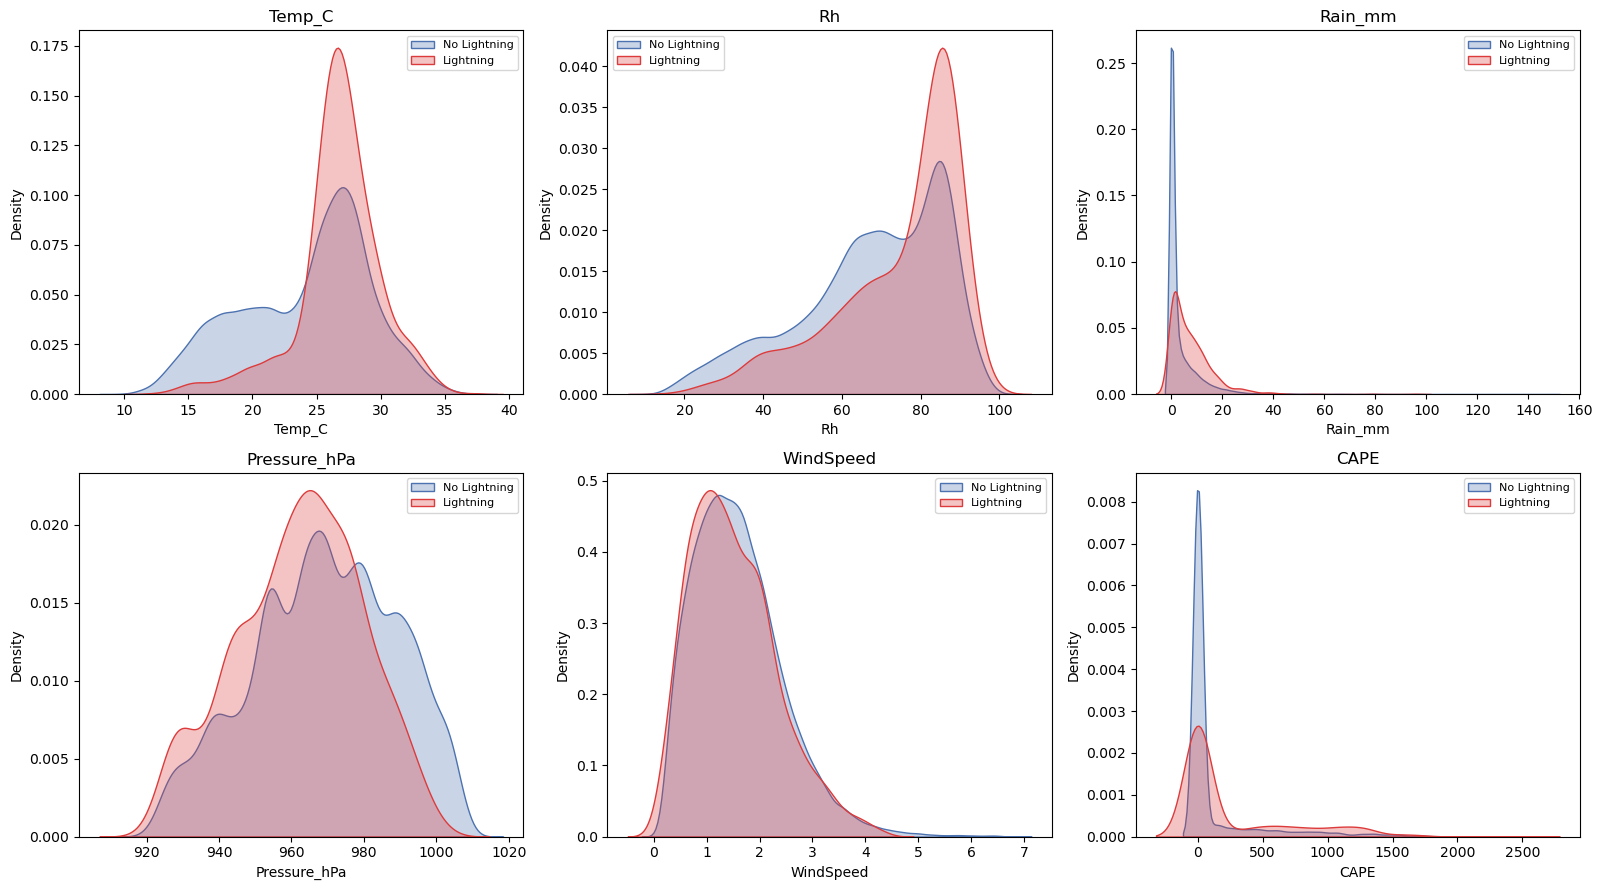

If a feature's two curves overlap heavily, it has weak predictive power.
If they separate clearly, that feature is a strong signal.

 4. CORRELATION MATRIX
Lightning_Occurred    1.000000
Rain_mm               0.085565
Temp_C                0.080591
Rh                    0.062512
CAPE                  0.057963
WindSpeed            -0.016788
Pressure_hPa         -0.056407


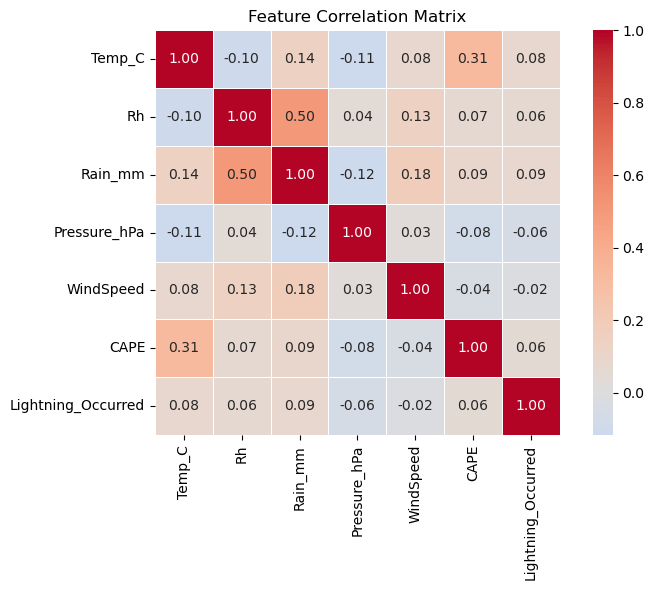

Features with |corr| < 0.05 against Lightning_Occurred contribute almost nothing linearly.

 5. TEMPORAL / SEASONAL PATTERNS
           sum  count       pct
Month_num                      
1           19   4092  0.464321
2           31   3718  0.833782
3           68   4092  1.661779
4          110   3960  2.777778
5          153   4092  3.739003
6          275   3960  6.944444
7          133   4092  3.250244
8          177   4092  4.325513
9          153   3960  3.863636
10         100   4092  2.443793
11          19   3960  0.479798
12          12   4070  0.294840


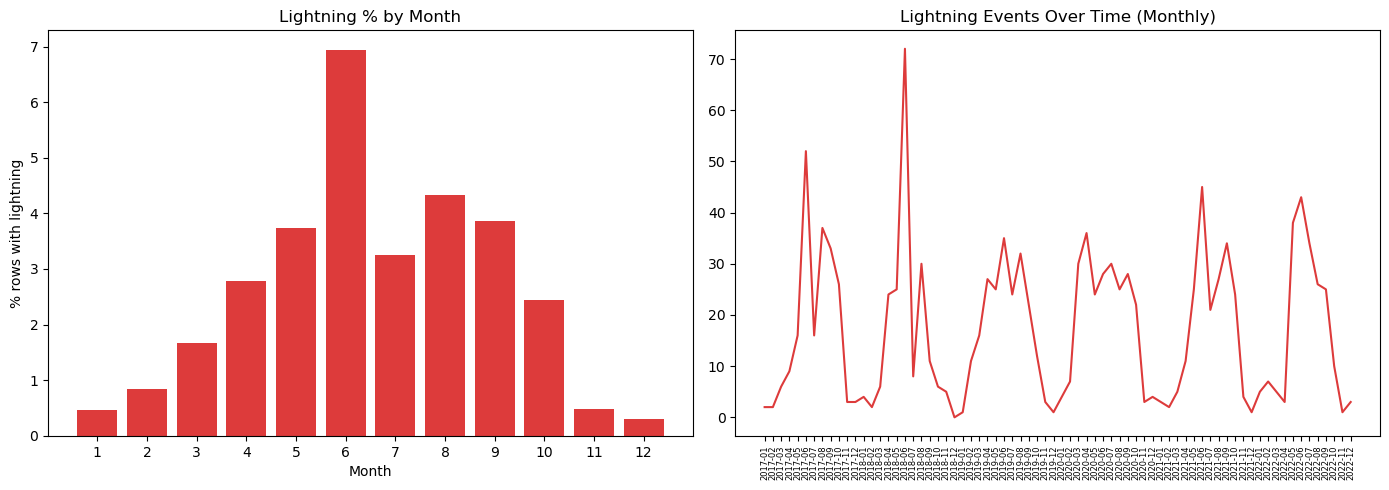

Confirms monsoon months (Jun-Sep) should show higher lightning % if data is sound.

 6. SPATIAL / DISTRICT-LEVEL PATTERNS
                sum  count       pct
District                            
Koderma         200   2190  9.132420
West Singhbhum   94   2190  4.292237
Gumla            94   2190  4.292237
Simdega          80   2190  3.652968
Ranchi           72   2190  3.287671
Khunti           64   2190  2.922374
Hazaribagh       60   2190  2.739726
Latehar          59   2190  2.694064
Giridih          58   2190  2.648402
Dumka            56   2190  2.557078


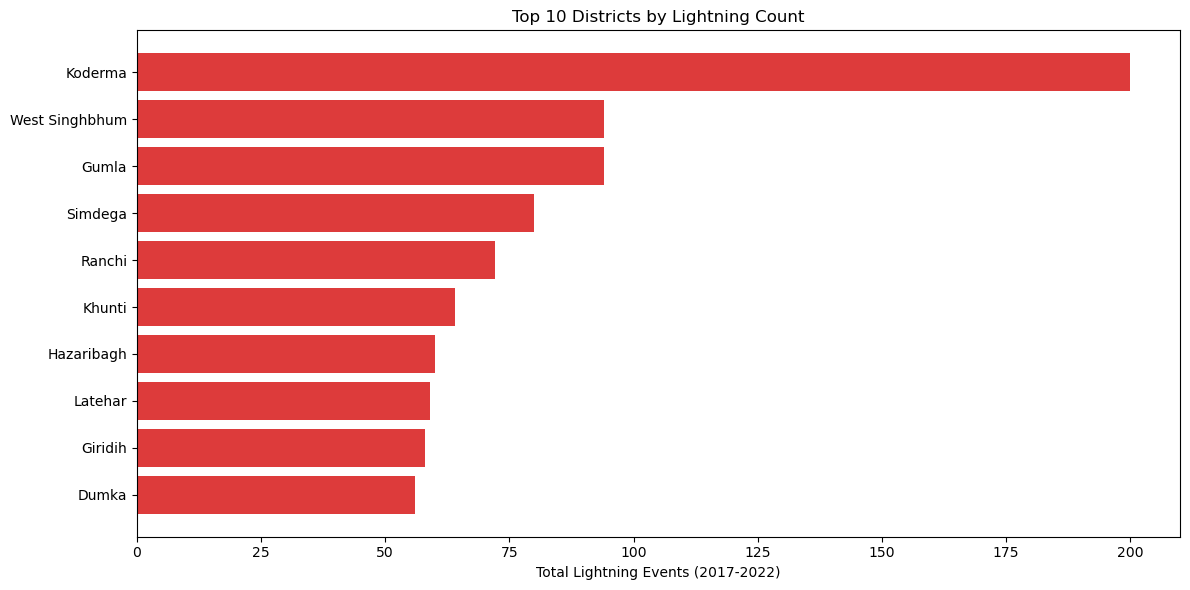


 7. OUTLIER CHECK


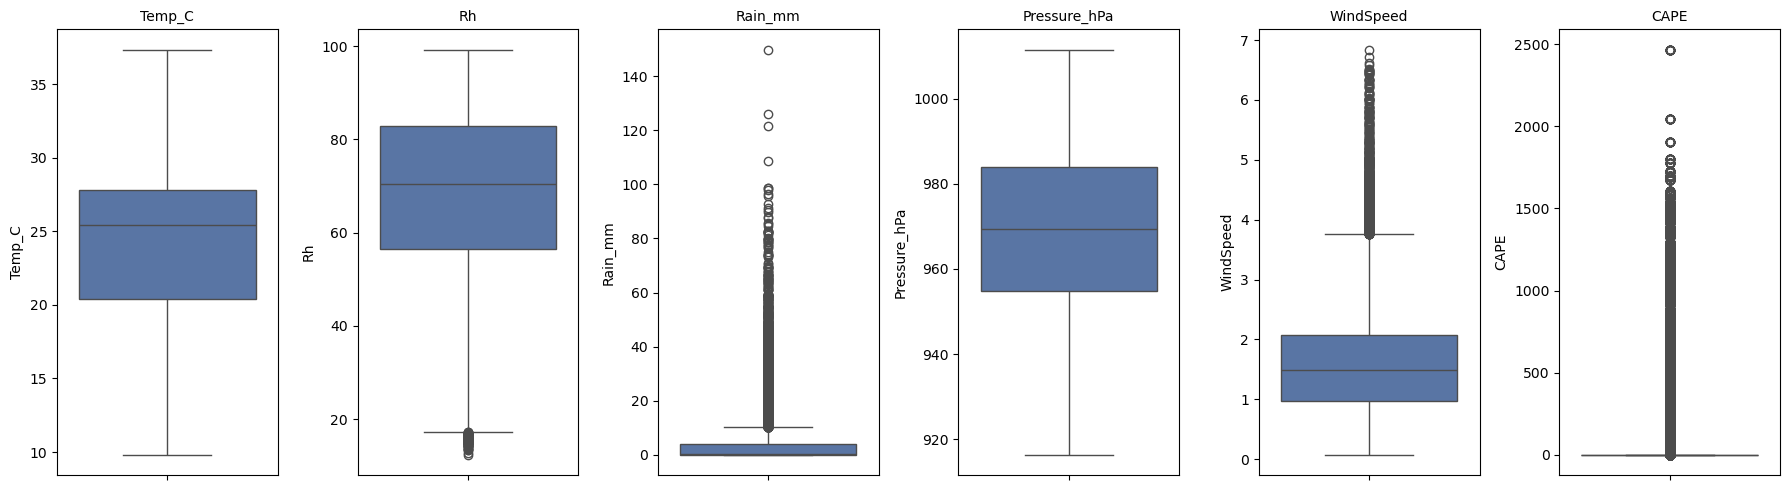

  Temp_C          outliers: 0 (0.0%)
  Rh              outliers: 121 (0.3%)
  Rain_mm         outliers: 5,541 (11.5%)
  Pressure_hPa    outliers: 0 (0.0%)
  WindSpeed       outliers: 890 (1.8%)
  CAPE            outliers: 11,682 (24.2%)

 SUMMARY OF FINDINGS
1. Class imbalance: 2.59% positive — severe, needs resamipling/focal loss
2. Weak/near-zero correlation features: ['WindSpeed']
3. Strongest predictors by correlation:
Rain_mm         0.085565
Temp_C          0.080591
Rh              0.062512
CAPE            0.057963
Pressure_hPa   -0.056407
4. Check eda_02_coverage_over_time.png for any feature with gaps (e.g. CAPE)
5. Check eda_05_temporal_patterns.png — lightning should peak Jun-Sep
6. Top lightning district: Koderma (200 events)


In [17]:
# ============================================================
# COMPLETE EDA — Understand your dataset before modeling
# Run this right after Cell 5 (after final_df is created)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = final_df.copy()

# Force numeric conversion (same fix as before)
numeric_cols = ['Pressure_hPa', 'Rh', 'Rain_mm', 'Temp_C', 'WindSpeed',
                'CAPE', 'Events', 'Radiance', 'Latitude', 'Longitude']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print("="*70)
print(" DATASET OVERVIEW")
print("="*70)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Districts: {df['District'].nunique()}")
print(f"\nColumn summary:")
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.count(),
    'null_pct': (df.isna().sum() / len(df) * 100).round(1),
    'zero_pct': ((df == 0).sum() / len(df) * 100).round(1),
    'nunique': df.nunique()
})
print(summary.to_string())


# ════════════════════════════════════════════════════════════
# 1. CLASS IMBALANCE — the core problem
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" 1. CLASS IMBALANCE")
print("="*70)
counts = df['Lightning_Occurred'].value_counts()
pct    = df['Lightning_Occurred'].value_counts(normalize=True) * 100
print(f"No lightning (0): {counts[0]:,} rows ({pct[0]:.2f}%)")
print(f"Lightning (1)   : {counts[1]:,} rows ({pct[1]:.2f}%)")
print(f"Imbalance ratio : 1:{counts[0]/counts[1]:.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(counts, labels=['No Lightning', 'Lightning'], autopct='%1.2f%%',
            colors=['#4C72B0', '#DD3B3B'], startangle=90)
axes[0].set_title('Overall Class Balance')

yearly = df.groupby(df['Date'].dt.year)['Lightning_Occurred'].agg(['sum', 'count'])
yearly['pct'] = yearly['sum'] / yearly['count'] * 100
axes[1].bar(yearly.index, yearly['pct'], color='#DD3B3B')
axes[1].set_title('Lightning % by Year')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('% rows with lightning')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'eda_01_class_balance.png'), dpi=120)
plt.show(); plt.close()


# ════════════════════════════════════════════════════════════
# 2. MISSINGNESS / DATA COVERAGE — find hidden gaps like CAPE
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" 2. DATA COVERAGE OVER TIME (zero/missing check per feature)")
print("="*70)

feature_cols = ['Temp_C', 'Rh', 'Rain_mm', 'Pressure_hPa', 'WindSpeed', 'CAPE']
feature_cols = [c for c in feature_cols if c in df.columns]

coverage = df.groupby(df['Date'].dt.to_period('M'))[feature_cols].apply(
    lambda x: (x != 0).mean() * 100
)
fig, ax = plt.subplots(figsize=(14, 5))
for col in feature_cols:
    ax.plot(coverage.index.astype(str), coverage[col], label=col, marker='o', markersize=2)
ax.set_title('Feature Coverage Over Time (% non-zero per month)')
ax.set_ylabel('% non-zero')
ax.legend(fontsize=9)
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'eda_02_coverage_over_time.png'), dpi=120)
plt.show(); plt.close()
print("Look for any line that DROPS TO 0 partway through — that's a hidden coverage gap (like CAPE).")


# ════════════════════════════════════════════════════════════
# 3. FEATURE DISTRIBUTIONS — split by lightning vs no lightning
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" 3. FEATURE DISTRIBUTIONS (Lightning vs No Lightning)")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    if i >= len(axes): break
    sns.kdeplot(df[df['Lightning_Occurred']==0][col], ax=axes[i],
                label='No Lightning', color='#4C72B0', fill=True, alpha=0.3)
    sns.kdeplot(df[df['Lightning_Occurred']==1][col], ax=axes[i],
                label='Lightning', color='#DD3B3B', fill=True, alpha=0.3)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'eda_03_feature_distributions.png'), dpi=120)
plt.show(); plt.close()
print("If a feature's two curves overlap heavily, it has weak predictive power.")
print("If they separate clearly, that feature is a strong signal.")


# ════════════════════════════════════════════════════════════
# 4. CORRELATION HEATMAP — feature relationships + target correlation
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" 4. CORRELATION MATRIX")
print("="*70)

corr_cols = feature_cols + ['Lightning_Occurred']
corr = df[corr_cols].corr()
print(corr['Lightning_Occurred'].sort_values(ascending=False).to_string())

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'eda_04_correlation.png'), dpi=120)
plt.show(); plt.close()
print("Features with |corr| < 0.05 against Lightning_Occurred contribute almost nothing linearly.")


# ════════════════════════════════════════════════════════════
# 5. TEMPORAL PATTERNS — monthly / seasonal lightning trends
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" 5. TEMPORAL / SEASONAL PATTERNS")
print("="*70)

df['Month_num'] = df['Date'].dt.month
monthly = df.groupby('Month_num')['Lightning_Occurred'].agg(['sum','count'])
monthly['pct'] = monthly['sum'] / monthly['count'] * 100
print(monthly)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(monthly.index, monthly['pct'], color='#DD3B3B')
axes[0].set_title('Lightning % by Month')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('% rows with lightning')
axes[0].set_xticks(range(1,13))

daily_trend = df.groupby(df['Date'].dt.to_period('M'))['Lightning_Occurred'].sum()
axes[1].plot(daily_trend.index.astype(str), daily_trend.values, color='#DD3B3B')
axes[1].set_title('Lightning Events Over Time (Monthly)')
plt.setp(axes[1].get_xticklabels(), rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'eda_05_temporal_patterns.png'), dpi=120)
plt.show(); plt.close()
print("Confirms monsoon months (Jun-Sep) should show higher lightning % if data is sound.")


# ════════════════════════════════════════════════════════════
# 6. SPATIAL PATTERNS — which districts matter
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" 6. SPATIAL / DISTRICT-LEVEL PATTERNS")
print("="*70)

district_stats = df.groupby('District')['Lightning_Occurred'].agg(['sum','count'])
district_stats['pct'] = district_stats['sum'] / district_stats['count'] * 100
district_stats = district_stats.sort_values('sum', ascending=False)
print(district_stats.head(10))

plt.figure(figsize=(12, 6))
top10 = district_stats.head(10)
plt.barh(top10.index[::-1], top10['sum'][::-1], color='#DD3B3B')
plt.xlabel('Total Lightning Events (2017-2022)')
plt.title('Top 10 Districts by Lightning Count')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'eda_06_district_ranking.png'), dpi=120)
plt.show(); plt.close()


# ════════════════════════════════════════════════════════════
# 7. OUTLIERS — boxplots per feature
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" 7. OUTLIER CHECK")
print("="*70)

fig, axes = plt.subplots(1, len(feature_cols), figsize=(3*len(feature_cols), 5))
for i, col in enumerate(feature_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#4C72B0')
    axes[i].set_title(col, fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'eda_07_outliers.png'), dpi=120)
plt.show(); plt.close()

for col in feature_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = ((df[col] < q1-1.5*iqr) | (df[col] > q3+1.5*iqr)).sum()
    print(f"  {col:<15} outliers: {outliers:,} ({outliers/len(df)*100:.1f}%)")


# ════════════════════════════════════════════════════════════
# 8. SUMMARY — what the EDA tells you
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" SUMMARY OF FINDINGS")
print("="*70)
weak_features = corr['Lightning_Occurred'].drop('Lightning_Occurred')
weak_features = weak_features[abs(weak_features) < 0.05].index.tolist()
strong_features = corr['Lightning_Occurred'].drop('Lightning_Occurred')
strong_features = strong_features[abs(strong_features) >= 0.05].sort_values(ascending=False)

print(f"1. Class imbalance: {pct[1]:.2f}% positive — severe, needs resamipling/focal loss")
print(f"2. Weak/near-zero correlation features: {weak_features}")
print(f"3. Strongest predictors by correlation:\n{strong_features.to_string()}")
print(f"4. Check eda_02_coverage_over_time.png for any feature with gaps (e.g. CAPE)")
print(f"5. Check eda_05_temporal_patterns.png — lightning should peak Jun-Sep")
print(f"6. Top lightning district: {district_stats.index[0]} "
      f"({district_stats.iloc[0]['sum']:.0f} events)")

In [ ]:
# ============================================================
# POST-MERGE ANALYSIS — specific to the merged dataset
# Run this right after Cell 5 (after final_df is created)
# Complements the general EDA — focuses on MERGE QUALITY
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = final_df.copy()

numeric_cols = ['Pressure_hPa', 'Rh', 'Rain_mm', 'Temp_C', 'WindSpeed',
                'CAPE', 'Events', 'Radiance', 'Latitude', 'Longitude']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print("="*70)
print(" MERGE QUALITY ANALYSIS")
print(" Checking: did MET + LIS + CAPE actually combine correctly?")
print("="*70)
print(f"Final merged shape: {df.shape[0]:,} rows × {df.shape[1]} columns")


# ════════════════════════════════════════════════════════════
# 1. HOW MANY ROWS ACTUALLY GOT LIS DATA (the left join check)
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" 1. MET ↔ LIS MERGE SUCCESS RATE")
print("="*70)
print("Since the merge is MET LEFT JOIN LIS, most MET rows will have")
print("Events=0 simply because no lightning happened that day — NOT a bug.")
print("But we need to check the merge actually found matches at all.\n")

matched = (df['Events'] > 0).sum()
total   = len(df)
print(f"Rows where LIS data matched (Events>0): {matched:,} / {total:,} ({matched/total*100:.2f}%)")

# Cross check: total Events in final_df vs raw LIS file rows
print(f"\nFor comparison — raw LIS file had ~7,886 lightning detection records")
print(f"After aggregating to Date+District and merging: {matched:,} matched day-district rows")
print("If this number seems too low, the Date or District keys may not align")
print("(e.g., date format mismatch, leftover whitespace in district names).")


# ════════════════════════════════════════════════════════════
# 2. DATE ALIGNMENT CHECK — do MET and LIS actually cover the same days?
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" 2. DATE RANGE ALIGNMENT (MET vs LIS vs CAPE vs Final)")
print("="*70)

met_dates  = met_df['Date'] if 'met_df' in dir() else None
lis_dates  = lis_df['Date'] if 'lis_df' in dir() else None

print(f"MET   date range : {met_df['Date'].min().date()} → {met_df['Date'].max().date()}  "
      f"({met_df['Date'].nunique()} unique days)")
print(f"LIS   date range : {lis_df['Date'].min().date()} → {lis_df['Date'].max().date()}  "
      f"({lis_df['Date'].nunique()} unique days)")
if not cape_df.empty:
    print(f"CAPE  date range : {cape_df['Date'].min().date()} → {cape_df['Date'].max().date()}  "
          f"({cape_df['Date'].nunique()} unique days)")
print(f"FINAL date range : {df['Date'].min().date()} → {df['Date'].max().date()}  "
      f"({df['Date'].nunique()} unique days)")

# visualize overlap
fig, ax = plt.subplots(figsize=(14, 3))
sources = {'MET': met_df['Date'], 'LIS': lis_df['Date']}
if not cape_df.empty:
    sources['CAPE'] = cape_df['Date']

for i, (name, dates) in enumerate(sources.items()):
    monthly_presence = dates.dt.to_period('M').value_counts().sort_index()
    ax.scatter(monthly_presence.index.astype(str), [i]*len(monthly_presence),
               s=20, label=name)
ax.set_yticks(range(len(sources)))
ax.set_yticklabels(sources.keys())
ax.set_title('Data Source Coverage Timeline — gaps = missing months')
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'merge_01_date_coverage.png'), dpi=120)
plt.show(); plt.close()
print("\nLook for any source with GAPS (missing dots) — that's where merge will produce fake zeros.")


# ════════════════════════════════════════════════════════════
# 3. DISTRICT ALIGNMENT CHECK — do district names match exactly?
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" 3. DISTRICT NAME ALIGNMENT (MET vs LIS)")
print("="*70)

met_districts = set(met_df['District'].unique())
lis_districts = set(lis_df['District'].unique())

print(f"Districts in MET only : {met_districts - lis_districts}")
print(f"Districts in LIS only : {lis_districts - met_districts}")
print(f"Districts in BOTH     : {len(met_districts & lis_districts)} / "
      f"{len(met_districts | lis_districts)} total")

if met_districts - lis_districts or lis_districts - met_districts:
    print("\n⚠ MISMATCH FOUND — these districts won't merge correctly for those rows.")
else:
    print("\n✓ All district names align between sources.")


# ════════════════════════════════════════════════════════════
# 4. WHAT FRACTION OF EACH FEATURE SURVIVED THE MERGE
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" 4. FEATURE SURVIVAL RATE AFTER MERGE")
print("="*70)
print("Comparing non-zero rates BEFORE merge (raw) vs AFTER merge (final_df)\n")

survival = []
# MET-origin features
for col in ['Temp_C', 'Rh', 'Rain_mm', 'Pressure_hPa', 'WindSpeed']:
    if col in met_df.columns and col in df.columns:
        met_col = pd.to_numeric(met_df[col], errors='coerce').fillna(0)
        final_col = df[col]
        survival.append({
            'feature': col, 'source': 'MET',
            'pre_merge_nonzero_%': (met_col != 0).mean()*100,
            'post_merge_nonzero_%': (final_col != 0).mean()*100
        })
# LIS-origin features  
for col in ['Events', 'Radiance', 'Latitude', 'Longitude']:
    if col in lis_df.columns and col in df.columns:
        lis_col = pd.to_numeric(lis_df[col], errors='coerce').fillna(0)
        survival.append({
            'feature': col, 'source': 'LIS',
            'pre_merge_nonzero_%': (lis_col != 0).mean()*100,
            'post_merge_nonzero_%': (df[col] != 0).mean()*100
        })
# CAPE
if not cape_df.empty and 'CAPE' in df.columns:
    survival.append({
        'feature': 'CAPE', 'source': 'CAPE',
        'pre_merge_nonzero_%': (cape_df['CAPE'] != 0).mean()*100,
        'post_merge_nonzero_%': (df['CAPE'] != 0).mean()*100
    })

survival_df = pd.DataFrame(survival)
print(survival_df.to_string(index=False))

plt.figure(figsize=(10, 5))
x = np.arange(len(survival_df))
plt.bar(x - 0.2, survival_df['pre_merge_nonzero_%'], width=0.4, label='Before merge', color='#4C72B0')
plt.bar(x + 0.2, survival_df['post_merge_nonzero_%'], width=0.4, label='After merge', color='#DD3B3B')
plt.xticks(x, survival_df['feature'], rotation=30)
plt.ylabel('% non-zero rows')
plt.title('Feature Coverage: Before vs After Merge')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'merge_02_feature_survival.png'), dpi=120)
plt.show(); plt.close()
print("\nA big DROP after merge means many rows got matched to nothing (left join produced zeros).")


# ════════════════════════════════════════════════════════════
# 5. ROW EXPLOSION / DUPLICATION CHECK
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" 5. ROW COUNT SANITY CHECK")
print("="*70)
print(f"MET rows (before merge)        : {len(met_df):,}")
print(f"LIS rows (before merge)        : {len(lis_df):,}")
print(f"LIS aggregated (Date+District) : {lis_df.groupby(['Date','District']).size().shape[0]:,}")
print(f"Final merged rows               : {len(df):,}")
print("\nFinal rows should be very close to MET rows (since it's a LEFT JOIN on MET).")
print("If final rows >> MET rows, you have duplicate keys causing row multiplication.")
if len(df) > len(met_df) * 1.05:
    print("⚠ WARNING: Final dataset has significantly MORE rows than MET — check for duplicate Date+District in MET.")
elif abs(len(df) - len(met_df)) < len(met_df)*0.02:
    print("✓ Row count looks correct — no duplication detected.")


# ════════════════════════════════════════════════════════════
# 6. DOES LIGHTNING_OCCURRED ACTUALLY MATCH RAW LIS EVENTS?
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" 6. TARGET VARIABLE SANITY CHECK")
print("="*70)
raw_lightning_days = lis_df.groupby(['Date','District']).size().shape[0]
final_lightning_days = (df['Lightning_Occurred'] == 1).sum()
print(f"Unique Date+District combos with ANY lightning in raw LIS : {raw_lightning_days:,}")
print(f"Rows flagged Lightning_Occurred=1 in final merged dataset : {final_lightning_days:,}")
diff = raw_lightning_days - final_lightning_days
print(f"Difference: {diff:,}")
if abs(diff) > raw_lightning_days * 0.05:
    print("⚠ Mismatch >5% — some lightning days may be getting lost in the merge")
    print("  (likely cause: District name mismatch between MET and LIS for those rows)")
else:
    print("✓ Target variable correctly reflects raw lightning records.")


# ════════════════════════════════════════════════════════════
# SUMMARY
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" MERGE ANALYSIS SUMMARY")
print("="*70)
print(f"1. {matched:,}/{total:,} rows ({matched/total*100:.1f}%) have real lightning data")
print(f"2. District alignment: {'CLEAN' if not (met_districts-lis_districts or lis_districts-met_districts) else 'MISMATCHED — see section 3'}")
print(f"3. Row count: {'OK' if abs(len(df)-len(met_df)) < len(met_df)*0.02 else 'CHECK FOR DUPLICATES'}")
print(f"4. Target variable loss: {diff:,} lightning-days ({'OK' if abs(diff) <= raw_lightning_days*0.05 else 'INVESTIGATE'})")
print(f"5. See merge_02_feature_survival.png for which features lost the most coverage")

In [ ]:
# Run this to see exactly where the two rankings diverge
intensity = lis_df.groupby("District")["Events"].sum().sort_values(ascending=False)
frequency = lis_df["District"].value_counts()

comparison = pd.DataFrame({
    'Total_Events': intensity,
    'Days_with_Lightning': frequency
}).fillna(0)
comparison['Events_Rank'] = comparison['Total_Events'].rank(ascending=False)
comparison['Freq_Rank']   = comparison['Days_with_Lightning'].rank(ascending=False)
comparison['Rank_Diff']   = comparison['Events_Rank'] - comparison['Freq_Rank']

print("Top 5 by Total Events:")
print(comparison.sort_values('Events_Rank').head(5)[['Total_Events','Events_Rank']])

print("\nTop 5 by Frequency (days):")
print(comparison.sort_values('Freq_Rank').head(5)[['Days_with_Lightning','Freq_Rank']])

print("\nDistricts where rankings disagree most:")
print(comparison.sort_values('Rank_Diff', key=abs, ascending=False).head(10))

In [ ]:
# Verify Events totals match between raw LIS and final merged dataset
raw_totals = lis_df.groupby("District")["Events"].sum().sort_values(ascending=False)
final_totals = final_df.groupby("District")["Events"].sum().sort_values(ascending=False)

print("Raw LIS top 5:", raw_totals.head(5).index.tolist())
print("Final merged top 5:", final_totals.head(5).index.tolist())
print("\nDo they match?", raw_totals.head(5).index.tolist() == final_totals.head(5).index.tolist())

# Show side by side
compare = pd.DataFrame({'raw_lis': raw_totals, 'final_merged': final_totals}).fillna(0)
compare['diff'] = compare['raw_lis'] - compare['final_merged']
print(compare[compare['diff'] != 0])  # should be empty if merge preserved everything

In [ ]:
# ============================================================
# DISTRICT-WISE LIGHTNING COUNT — ALL YEARS, FULL BREAKDOWN
# Run after Cell 5 (uses lis_df and/or final_df)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Use raw LIS data (actual lightning detection records)
df = lis_df.copy()
df['Year'] = df['Date'].dt.year

# ════════════════════════════════════════════════════════════
# 1. OVERALL COUNT PER DISTRICT (all years combined)
# ════════════════════════════════════════════════════════════
print("="*70)
print(" DISTRICT-WISE LIGHTNING COUNT — ALL YEARS (2017-2022)")
print("="*70)

district_total = df.groupby('District').agg(
    Total_Events=('Events', 'sum'),
    Days_with_Lightning=('District', 'count'),
    Avg_Radiance=('Radiance', 'mean') if 'Radiance' in df.columns else ('Events', 'mean')
).sort_values('Total_Events', ascending=False)

district_total['Total_Events'] = district_total['Total_Events'].astype(int)
print(district_total.to_string())

# Bar chart — all districts, total events
plt.figure(figsize=(14, 7))
colors = sns.color_palette("rocket_r", len(district_total))
bars = plt.bar(district_total.index, district_total['Total_Events'], color=colors)
plt.xticks(rotation=75, ha='right')
plt.ylabel('Total Lightning Events (2017-2022)')
plt.title('Total Lightning Events by District — All Years Combined')
for bar, val in zip(bars, district_total['Total_Events']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(district_total['Total_Events'])*0.01,
              f'{val}', ha='center', fontsize=8, rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'district_01_total_all_years.png'), dpi=130)
plt.show(); plt.close()


# ════════════════════════════════════════════════════════════
# 2. YEAR-WISE BREAKDOWN PER DISTRICT (table)
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" YEAR-WISE LIGHTNING EVENTS PER DISTRICT")
print("="*70)

year_district = df.pivot_table(
    index='District', columns='Year', values='Events',
    aggfunc='sum', fill_value=0
)
year_district['Total'] = year_district.sum(axis=1)
year_district = year_district.sort_values('Total', ascending=False)
print(year_district.astype(int).to_string())


# ════════════════════════════════════════════════════════════
# 3. HEATMAP — District x Year (the clearest way to see patterns)
# ════════════════════════════════════════════════════════════
plt.figure(figsize=(10, 12))
heatmap_data = year_district.drop(columns='Total')
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Total Events'})
plt.title('Lightning Events Heatmap — District × Year')
plt.xlabel('Year'); plt.ylabel('District')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'district_02_year_heatmap.png'), dpi=130)
plt.show(); plt.close()


# ════════════════════════════════════════════════════════════
# 4. TREND LINES — top 5 districts, year over year
# ════════════════════════════════════════════════════════════
top5 = district_total.head(5).index.tolist()
print(f"\nTop 5 districts: {top5}")

plt.figure(figsize=(12, 6))
for dist in top5:
    plt.plot(year_district.columns[:-1], year_district.loc[dist].values[:-1],
              marker='o', linewidth=2, label=dist)
plt.xlabel('Year'); plt.ylabel('Total Lightning Events')
plt.title('Lightning Trend Over Years — Top 5 Districts')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'district_03_top5_trend.png'), dpi=130)
plt.show(); plt.close()


# ════════════════════════════════════════════════════════════
# 5. DAYS-WITH-LIGHTNING vs TOTAL EVENTS (intensity vs frequency)
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" FREQUENCY vs INTENSITY — are they the same districts?")
print("="*70)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(district_total['Days_with_Lightning'],
                      district_total['Total_Events'],
                      s=100, c=range(len(district_total)), cmap='viridis')
for i, dist in enumerate(district_total.index):
    ax.annotate(dist, (district_total['Days_with_Lightning'].iloc[i],
                        district_total['Total_Events'].iloc[i]),
                fontsize=8, xytext=(5,5), textcoords='offset points')
ax.set_xlabel('Days with Lightning (frequency)')
ax.set_ylabel('Total Events (intensity)')
ax.set_title('District Comparison: Frequency vs Intensity')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'district_04_freq_vs_intensity.png'), dpi=130)
plt.show(); plt.close()

print("\nDistricts in TOP 5 by events but NOT top 5 by frequency (or vice versa):")
top5_by_freq = district_total.sort_values('Days_with_Lightning', ascending=False).head(5).index.tolist()
top5_by_events = district_total.head(5).index.tolist()
print(f"  Top 5 by Total Events     : {top5_by_events}")
print(f"  Top 5 by Days w/ Lightning: {top5_by_freq}")
print(f"  Same districts in both?    {set(top5_by_events) == set(top5_by_freq)}")
if set(top5_by_events) != set(top5_by_freq):
    print(f"  Districts that differ      : {set(top5_by_events) ^ set(top5_by_freq)}")


# ════════════════════════════════════════════════════════════
# 6. STACKED BAR — yearly contribution per district (top 10)
# ════════════════════════════════════════════════════════════
top10_districts = district_total.head(10).index.tolist()
stacked_data = year_district.loc[top10_districts].drop(columns='Total')

fig, ax = plt.subplots(figsize=(13, 7))
stacked_data.T.plot(kind='bar', stacked=True, ax=ax,
                      colormap='tab20', width=0.7)
ax.set_xlabel('Year'); ax.set_ylabel('Total Lightning Events')
ax.set_title('Yearly Lightning Contribution — Top 10 Districts (Stacked)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'district_05_stacked_yearly.png'), dpi=130)
plt.show(); plt.close()


# ════════════════════════════════════════════════════════════
# SUMMARY
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" SUMMARY")
print("="*70)
print(f"Total districts with lightning data : {df['District'].nunique()}")
print(f"Highest total events  : {district_total.index[0]} ({district_total['Total_Events'].iloc[0]} events)")
print(f"Most frequent days    : {district_total.sort_values('Days_with_Lightning', ascending=False).index[0]} "
      f"({district_total['Days_with_Lightning'].max()} days)")
print(f"Lowest total events   : {district_total.index[-1]} ({district_total['Total_Events'].iloc[-1]} events)")
print(f"\nAll plots saved to: {RESULTS_DIR}/")
print("  district_01_total_all_years.png  — overall bar chart")
print("  district_02_year_heatmap.png     — district x year heatmap")
print("  district_03_top5_trend.png       — top 5 trend lines")
print("  district_04_freq_vs_intensity.png — frequency vs intensity scatter")
print("  district_05_stacked_yearly.png   — stacked yearly contribution")

 1. OVERALL YEARLY TREND
Year
2017    39402
2018    40861
2019    47079
2020    63740
2021    47798
2022    49941

Trend slope: 2576.20 events/year
R-squared  : 0.3079
P-value    : 0.2531  (not statistically significant)
→ Lightning activity is INCREASING by ~2576 events/year


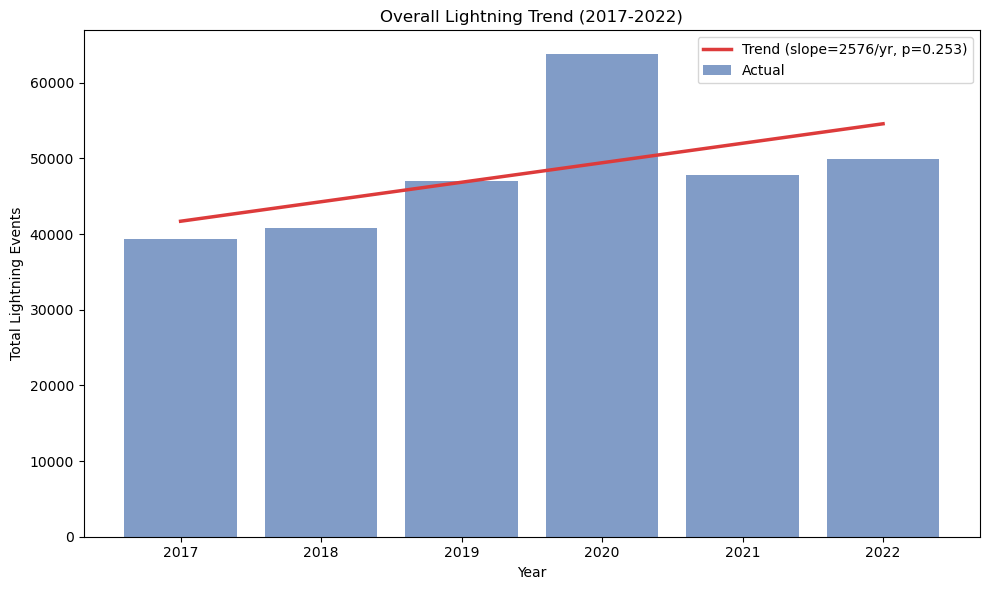


 2. SEASONAL (MONTHLY) TREND ACROSS ALL YEARS
Month
1       313.5
2       592.8
3      1568.0
4      5489.7
5      7786.5
6     10740.2
7      3740.8
8      6211.5
9      8150.7
10     3205.8
11      214.2
12      123.2


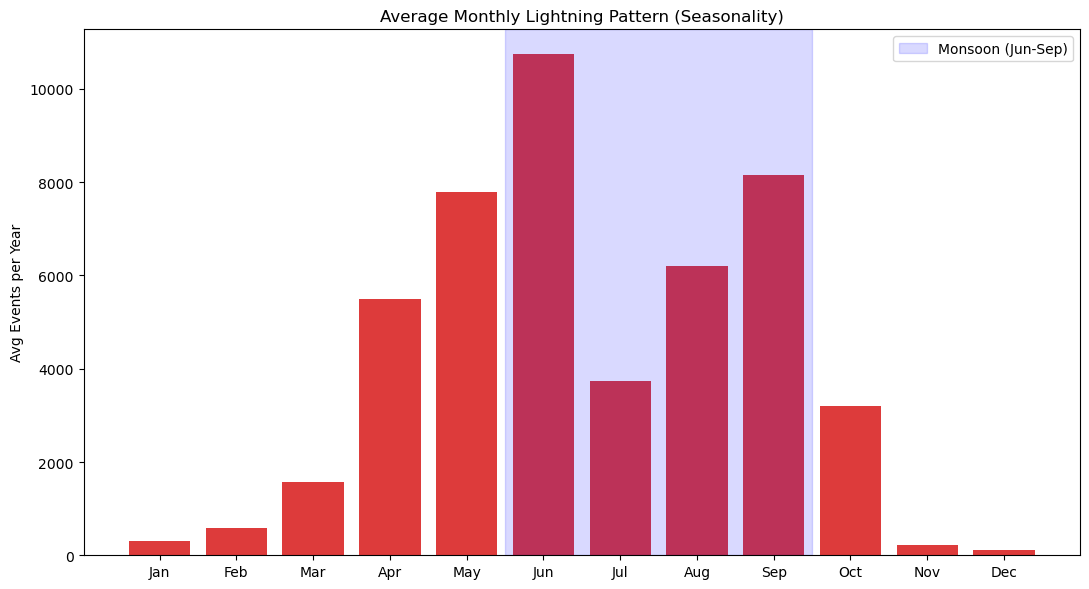


Confirms whether your data follows expected monsoon physics (peak Jun-Sep).

 3. YEAR-OVER-YEAR % CHANGE
Year
2017     NaN
2018     3.7
2019    15.2
2020    35.4
2021   -25.0
2022     4.5


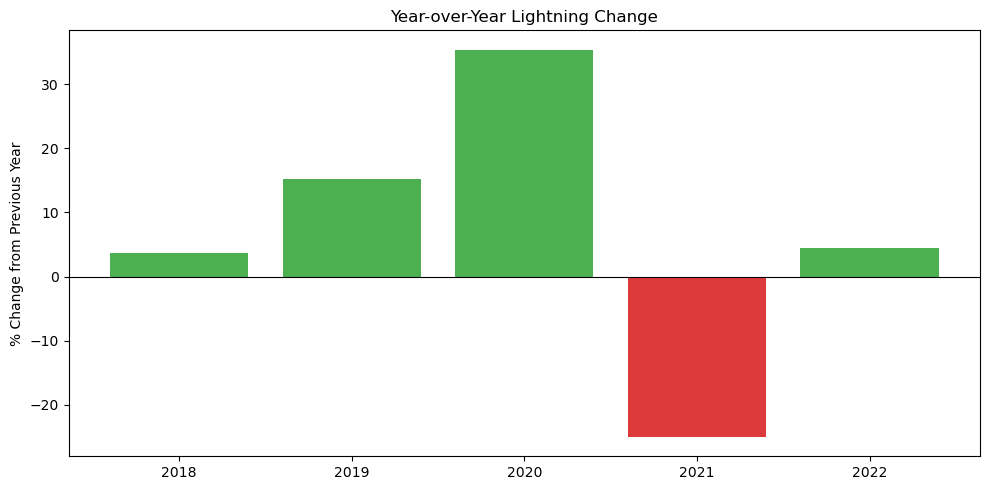


 4. PER-DISTRICT TREND (increasing or decreasing risk?)
           District       Slope       R2  P_value      Trend  Total_Events
     West Singhbhum  725.742857 0.192905 0.383549 Increasing         36675
            Deoghar  699.142857 0.538911 0.096650 Increasing         13970
             Palamu  446.657143 0.441621 0.149920 Increasing         10359
             Chatra  430.457143 0.386615 0.187520 Increasing          8302
            Latehar  251.828571 0.284185 0.276113 Increasing         10004
             Bokaro  250.142857 0.567856 0.083614 Increasing          2319
              Dumka  222.800000 0.082912 0.580021 Increasing         19528
              Godda  202.314286 0.303889 0.256869 Increasing          5549
            Ramgarh  192.657143 0.196282 0.378924 Increasing          6859
             Khunti  152.428571 0.057357 0.647627 Increasing         14731
            Jamtara  111.028571 0.089640 0.564321 Increasing          5866
            Simdega   97.142857 0.005345 0.

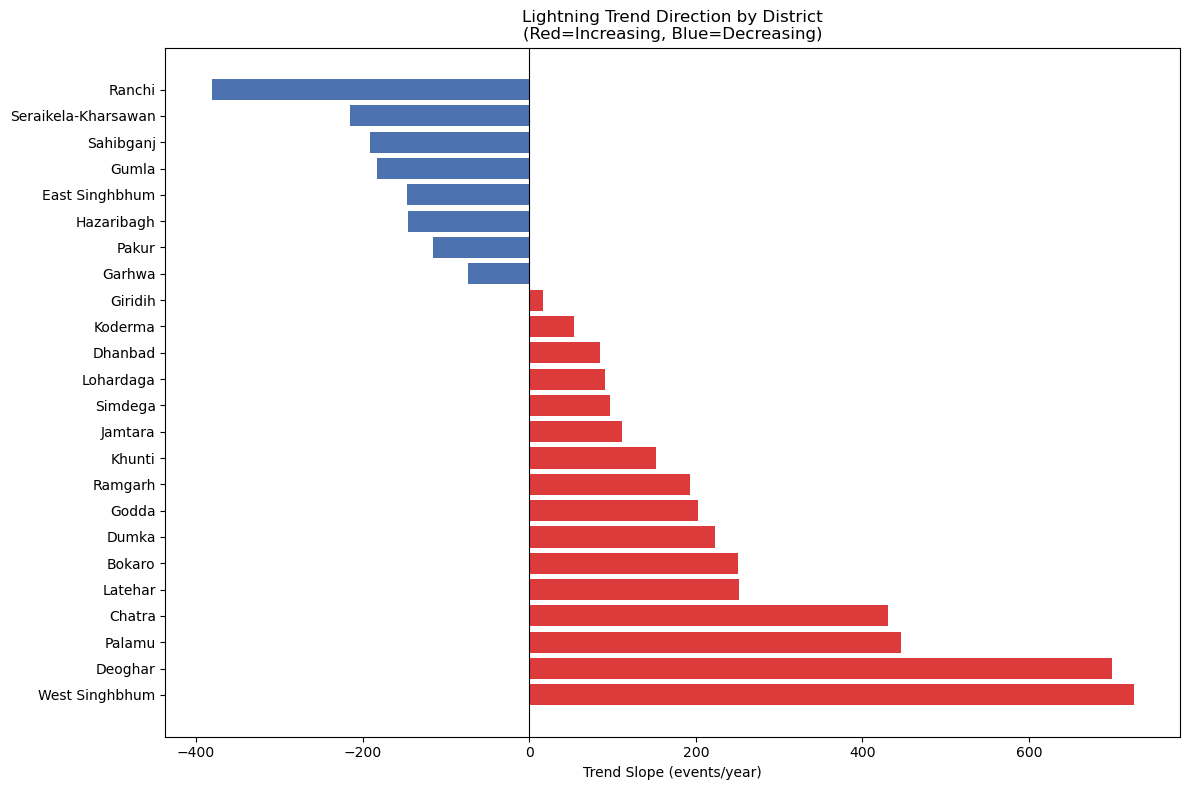


Districts with INCREASING risk: ['West Singhbhum', 'Deoghar', 'Palamu', 'Chatra', 'Latehar', 'Bokaro', 'Dumka', 'Godda', 'Ramgarh', 'Khunti', 'Jamtara', 'Simdega', 'Lohardaga', 'Dhanbad', 'Koderma', 'Giridih']
Districts with DECREASING risk: ['Garhwa', 'Pakur', 'Hazaribagh', 'East Singhbhum', 'Gumla', 'Sahibganj', 'Seraikela-Kharsawan', 'Ranchi']

 5. MONTHLY TIME SERIES WITH SMOOTHED TREND


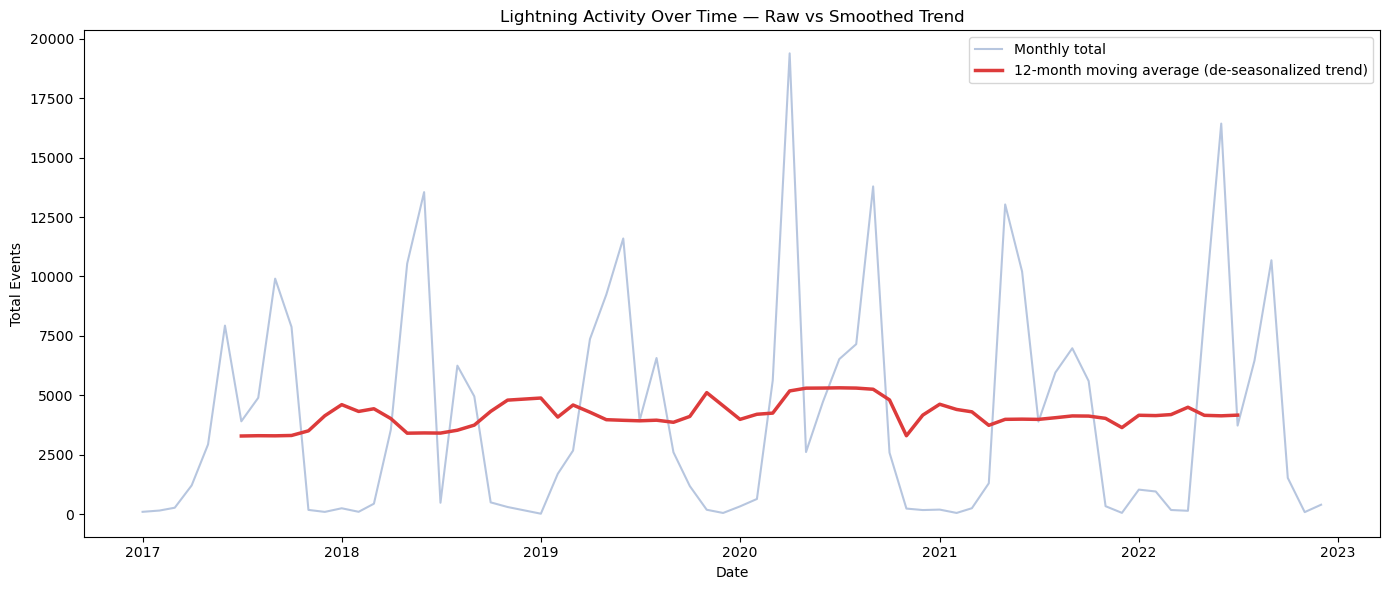


 TREND ANALYSIS SUMMARY
1. Overall trend: increasing (+2576 events/year, p=0.253, not significant)
2. Peak season: Jun (10740 avg events)
3. Worst year: 2020 (63740 events)
4. Districts trending UP  : 16
5. Districts trending DOWN: 8


In [18]:
# ============================================================
# TREND ANALYSIS — Is lightning increasing/decreasing over time?
# Run after Cell 5 (uses lis_df)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

df = lis_df.copy()
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# ════════════════════════════════════════════════════════════
# 1. OVERALL YEARLY TREND (with linear regression line)
# ════════════════════════════════════════════════════════════
print("="*70)
print(" 1. OVERALL YEARLY TREND")
print("="*70)

yearly_total = df.groupby('Year')['Events'].sum()
print(yearly_total.to_string())

years = yearly_total.index.values
values = yearly_total.values
slope, intercept, r_value, p_value, std_err = stats.linregress(years, values)

print(f"\nTrend slope: {slope:.2f} events/year")
print(f"R-squared  : {r_value**2:.4f}")
print(f"P-value    : {p_value:.4f}  ({'SIGNIFICANT' if p_value < 0.05 else 'not statistically significant'})")
if slope > 0:
    print(f"→ Lightning activity is INCREASING by ~{slope:.0f} events/year")
else:
    print(f"→ Lightning activity is DECREASING by ~{abs(slope):.0f} events/year")

plt.figure(figsize=(10, 6))
plt.bar(years, values, color='#4C72B0', alpha=0.7, label='Actual')
trend_line = slope * years + intercept
plt.plot(years, trend_line, color='#DD3B3B', linewidth=2.5,
         label=f'Trend (slope={slope:.0f}/yr, p={p_value:.3f})')
plt.xlabel('Year'); plt.ylabel('Total Lightning Events')
plt.title('Overall Lightning Trend (2017-2022)')
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'trend_01_overall_yearly.png'), dpi=130)
plt.show(); plt.close()


# ════════════════════════════════════════════════════════════
# 2. SEASONAL TREND — month-wise pattern across all years
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" 2. SEASONAL (MONTHLY) TREND ACROSS ALL YEARS")
print("="*70)

monthly_avg = df.groupby('Month')['Events'].sum() / df['Year'].nunique()
print(monthly_avg.round(1).to_string())

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=(11, 6))
plt.bar(range(1,13), monthly_avg.values, color='#DD3B3B')
plt.xticks(range(1,13), month_names)
plt.ylabel('Avg Events per Year')
plt.title('Average Monthly Lightning Pattern (Seasonality)')
plt.axvspan(5.5, 9.5, alpha=0.15, color='blue', label='Monsoon (Jun-Sep)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'trend_02_seasonal_pattern.png'), dpi=130)
plt.show(); plt.close()
print("\nConfirms whether your data follows expected monsoon physics (peak Jun-Sep).")


# ════════════════════════════════════════════════════════════
# 3. YEAR-OVER-YEAR % CHANGE
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" 3. YEAR-OVER-YEAR % CHANGE")
print("="*70)

yoy_change = yearly_total.pct_change() * 100
print(yoy_change.round(1).to_string())

plt.figure(figsize=(10, 5))
colors = ['#DD3B3B' if v < 0 else '#4CAF50' for v in yoy_change.dropna()]
plt.bar(yoy_change.dropna().index, yoy_change.dropna().values, color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('% Change from Previous Year')
plt.title('Year-over-Year Lightning Change')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'trend_03_yoy_change.png'), dpi=130)
plt.show(); plt.close()


# ════════════════════════════════════════════════════════════
# 4. DISTRICT-LEVEL TREND — which districts trending UP vs DOWN
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" 4. PER-DISTRICT TREND (increasing or decreasing risk?)")
print("="*70)

district_trends = []
for dist in df['District'].unique():
    sub = df[df['District'] == dist].groupby('Year')['Events'].sum()
    sub = sub.reindex(range(2017, 2023), fill_value=0)
    if len(sub) >= 3:
        s, i, r, p, se = stats.linregress(sub.index, sub.values)
        district_trends.append({
            'District': dist, 'Slope': s, 'R2': r**2, 'P_value': p,
            'Trend': 'Increasing' if s > 0 else 'Decreasing',
            'Total_Events': sub.sum()
        })

trend_df = pd.DataFrame(district_trends).sort_values('Slope', ascending=False)
print(trend_df.to_string(index=False))

plt.figure(figsize=(12, 8))
colors = ['#DD3B3B' if t == 'Increasing' else '#4C72B0' for t in trend_df['Trend']]
plt.barh(trend_df['District'], trend_df['Slope'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Trend Slope (events/year)')
plt.title('Lightning Trend Direction by District\n(Red=Increasing, Blue=Decreasing)')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'trend_04_district_trends.png'), dpi=130)
plt.show(); plt.close()

print(f"\nDistricts with INCREASING risk: {trend_df[trend_df['Trend']=='Increasing']['District'].tolist()}")
print(f"Districts with DECREASING risk: {trend_df[trend_df['Trend']=='Decreasing']['District'].tolist()}")


# ════════════════════════════════════════════════════════════
# 5. MOVING AVERAGE — smoothed trend (removes noise)
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" 5. MONTHLY TIME SERIES WITH SMOOTHED TREND")
print("="*70)

monthly_ts = df.groupby(df['Date'].dt.to_period('M'))['Events'].sum()
monthly_ts.index = monthly_ts.index.to_timestamp()
rolling_avg = monthly_ts.rolling(window=12, center=True).mean()  # 12-month moving avg

plt.figure(figsize=(14, 6))
plt.plot(monthly_ts.index, monthly_ts.values, alpha=0.4, color='#4C72B0', label='Monthly total')
plt.plot(rolling_avg.index, rolling_avg.values, color='#DD3B3B', linewidth=2.5,
         label='12-month moving average (de-seasonalized trend)')
plt.xlabel('Date'); plt.ylabel('Total Events')
plt.title('Lightning Activity Over Time — Raw vs Smoothed Trend')
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'trend_05_moving_average.png'), dpi=130)
plt.show(); plt.close()


# ════════════════════════════════════════════════════════════
# SUMMARY
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" TREND ANALYSIS SUMMARY")
print("="*70)
print(f"1. Overall trend: {'increasing' if slope>0 else 'decreasing'} "
      f"({slope:+.0f} events/year, p={p_value:.3f}, "
      f"{'significant' if p_value<0.05 else 'not significant'})")
print(f"2. Peak season: {month_names[monthly_avg.idxmax()-1]} "
      f"({monthly_avg.max():.0f} avg events)")
print(f"3. Worst year: {yearly_total.idxmax()} ({yearly_total.max():.0f} events)")
print(f"4. Districts trending UP  : {len(trend_df[trend_df['Trend']=='Increasing'])}")
print(f"5. Districts trending DOWN: {len(trend_df[trend_df['Trend']=='Decreasing'])}")

 STEP 1: Creating Risk Categories
Risk_Category
Low       46930
High       1212
Medium       38
Name: count, dtype: int64

Distribution:
Risk_Category
Low       97.405562
High       2.515567
Medium     0.078871
Name: proportion, dtype: float64


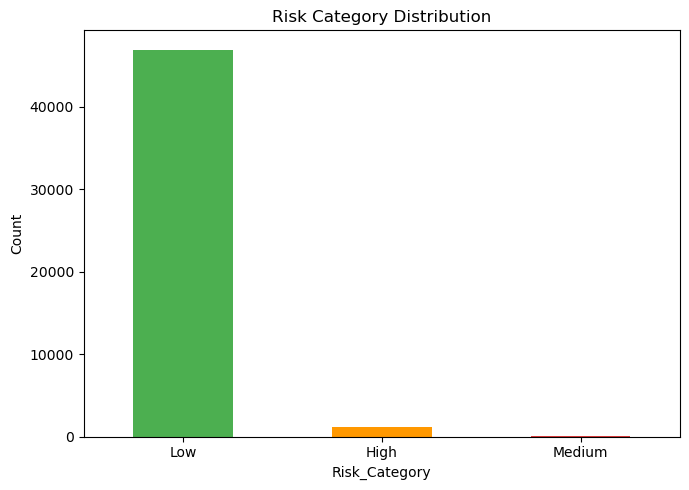


 STEP 2: Feature Engineering
Using 12 features: ['Temp_C', 'Rh', 'Rain_mm', 'Pressure_hPa', 'WindSpeed', 'month_sin', 'month_cos', 'is_monsoon', 'events_lag_1', 'events_lag_2', 'events_lag_3', 'events_rolling_7']

 STEP 3: Train/Test Split
Classes: {'High': 0, 'Low': 1, 'Medium': 2}
Train: 38544, Test: 9636

 STEP 4: Training Models

 RESULTS — Random Forest
Accuracy: 89.37%
              precision    recall  f1-score   support

        High       0.09      0.36      0.14       242
         Low       0.98      0.91      0.94      9386
      Medium       0.00      0.00      0.00         8

    accuracy                           0.89      9636
   macro avg       0.36      0.42      0.36      9636
weighted avg       0.96      0.89      0.92      9636


 RESULTS — XGBoost
Accuracy: 97.41%
              precision    recall  f1-score   support

        High       0.00      0.00      0.00       242
         Low       0.97      1.00      0.99      9386
      Medium       0.00      0.00      0

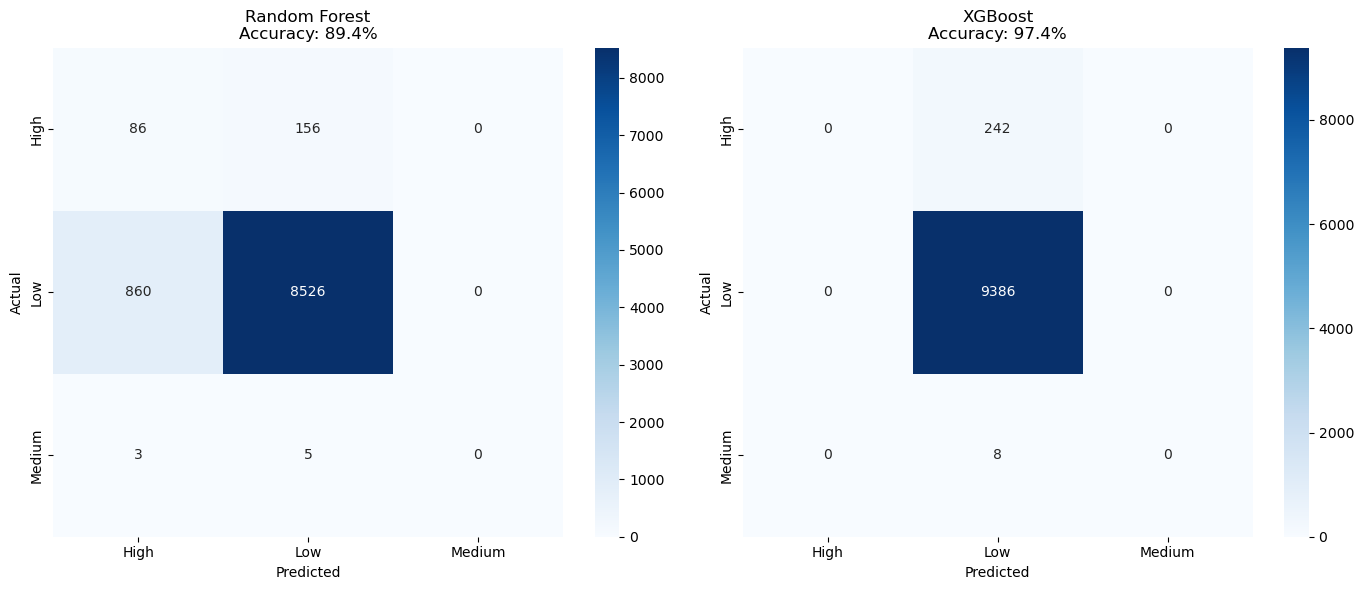


 FEATURE IMPORTANCE (Random Forest)
Rain_mm             0.206594
Temp_C              0.160472
Pressure_hPa        0.145700
WindSpeed           0.132877
Rh                  0.130451
month_cos           0.067144
events_rolling_7    0.059559
month_sin           0.046155
is_monsoon          0.016398
events_lag_2        0.014327
events_lag_3        0.012237
events_lag_1        0.008087


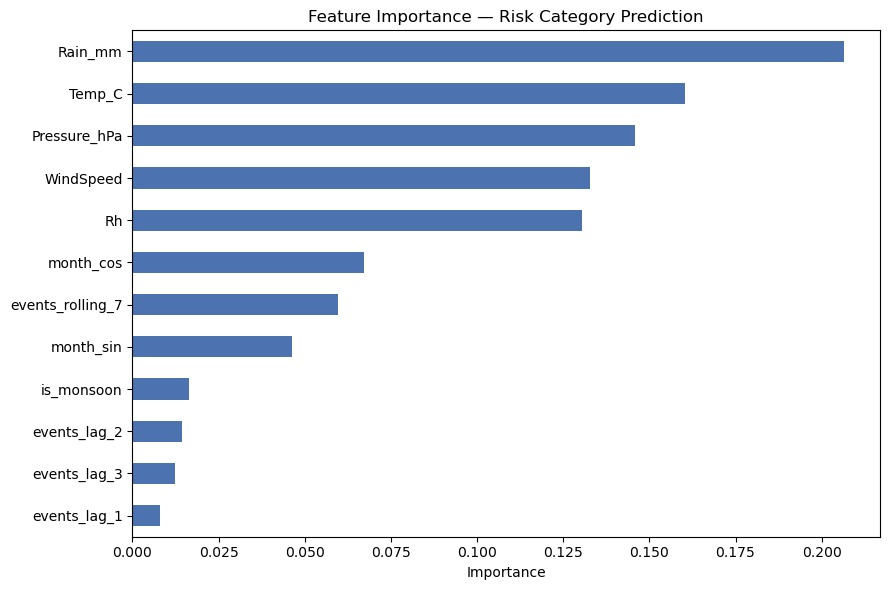


 DEMO: Predict Current Risk for Top Districts

  West Singhbhum:
    Predicted risk: Low
      High: 8.6%
      Low: 91.4%
      Medium: 0.0%

  Simdega:
    Predicted risk: Low
      High: 2.7%
      Low: 97.3%
      Medium: 0.0%

  Dumka:
    Predicted risk: Low
      High: 1.2%
      Low: 98.8%
      Medium: 0.0%

  Gumla:
    Predicted risk: Low
      High: 0.9%
      Low: 99.1%
      Medium: 0.0%

  Ranchi:
    Predicted risk: Low
      High: 1.2%
      Low: 98.8%
      Medium: 0.0%

 SUMMARY
Risk Category model trained on 12 features
RF Accuracy : 89.37%
XGB Accuracy: 97.41%
Most important feature: Rain_mm (0.207)

This reframes binary 97:3 imbalance into a 3-class problem,
which is generally easier to model and more actionable for warnings
(e.g. 'issue advisory if predicted risk = High').


In [22]:
# ============================================================
# RISK CATEGORY PREDICTION MODEL
# Predicts: Low / Medium / High lightning risk per district-day
# Run after Cell 5 (uses final_df)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb

df = final_df.copy()

numeric_cols = ['Pressure_hPa', 'Rh', 'Rain_mm', 'Temp_C', 'WindSpeed', 'CAPE', 'Events']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# ════════════════════════════════════════════════════════════
# 1. CREATE RISK CATEGORIES (instead of binary 0/1)
# ════════════════════════════════════════════════════════════
print("="*70)
print(" STEP 1: Creating Risk Categories")
print("="*70)

def categorize_risk(events):
    if events == 0:
        return 'Low'
    elif events <= 5:
        return 'Medium'
    else:
        return 'High'

df['Risk_Category'] = df['Events'].apply(categorize_risk)
print(df['Risk_Category'].value_counts())
print(f"\nDistribution:\n{df['Risk_Category'].value_counts(normalize=True)*100}")

plt.figure(figsize=(7,5))
df['Risk_Category'].value_counts().plot(kind='bar', color=['#4CAF50','#FF9800','#DD3B3B'])
plt.title('Risk Category Distribution')
plt.ylabel('Count'); plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'risk_01_category_distribution.png'), dpi=130)
plt.show(); plt.close()

# Still imbalanced, but far less severe than binary (typically Low~90%, Medium~7%, High~3%)


# ════════════════════════════════════════════════════════════
# 2. FEATURE ENGINEERING — same lag features as before
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" STEP 2: Feature Engineering")
print("="*70)

df = df.sort_values(['District', 'Date'])
df['hour_sin']  = 0  # daily data, no hour info — kept for consistency
df['month_num'] = df['Date'].dt.month
df['month_sin'] = np.sin(2*np.pi*df['month_num']/12)
df['month_cos'] = np.cos(2*np.pi*df['month_num']/12)
df['is_monsoon'] = df['month_num'].isin([6,7,8,9]).astype(int)

for lag in [1, 2, 3]:
    df[f'events_lag_{lag}'] = df.groupby('District')['Events'].shift(lag).fillna(0)

df['events_rolling_7'] = (df.groupby('District')['Events']
                            .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
                            .fillna(0))

DESIRED_FEATURES = ['Temp_C', 'Rh', 'Rain_mm', 'Pressure_hPa', 'WindSpeed',
                    'month_sin', 'month_cos', 'is_monsoon',
                    'events_lag_1', 'events_lag_2', 'events_lag_3', 'events_rolling_7']
features = [c for c in DESIRED_FEATURES if c in df.columns and df[c].nunique() > 1]
print(f"Using {len(features)} features: {features}")


# ════════════════════════════════════════════════════════════
# 3. ENCODE TARGET + TRAIN/TEST SPLIT
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" STEP 3: Train/Test Split")
print("="*70)

le = LabelEncoder()
df['Risk_Encoded'] = le.fit_transform(df['Risk_Category'])
print(f"Classes: {dict(zip(le.classes_, range(len(le.classes_))))}")

X = df[features].values
y = df['Risk_Encoded'].values

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")


# ════════════════════════════════════════════════════════════
# 4. TRAIN MULTI-CLASS MODELS
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" STEP 4: Training Models")
print("="*70)

# Random Forest with class weights
rf = RandomForestClassifier(
    n_estimators=300, max_depth=12, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# XGBoost multi-class
xgb_m = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    objective='multi:softmax', num_class=len(le.classes_),
    random_state=42
)
xgb_m.fit(X_train, y_train)
xgb_pred = xgb_m.predict(X_test)


# ════════════════════════════════════════════════════════════
# 5. EVALUATE
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" RESULTS — Random Forest")
print("="*70)
print(f"Accuracy: {accuracy_score(y_test, rf_pred)*100:.2f}%")
print(classification_report(y_test, rf_pred, target_names=le.classes_, zero_division=0))

print("\n" + "="*70)
print(" RESULTS — XGBoost")
print("="*70)
print(f"Accuracy: {accuracy_score(y_test, xgb_pred)*100:.2f}%")
print(classification_report(y_test, xgb_pred, target_names=le.classes_, zero_division=0))

# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, pred, name in zip(axes, [rf_pred, xgb_pred], ['Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, pred)*100:.1f}%')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'risk_02_confusion_matrices.png'), dpi=130)
plt.show(); plt.close()


# ════════════════════════════════════════════════════════════
# 6. FEATURE IMPORTANCE
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" FEATURE IMPORTANCE (Random Forest)")
print("="*70)

importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print(importance.to_string())

plt.figure(figsize=(9, 6))
importance.plot(kind='barh', color='#4C72B0')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Feature Importance — Risk Category Prediction')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'risk_03_feature_importance.png'), dpi=130)
plt.show(); plt.close()


# ════════════════════════════════════════════════════════════
# 7. PREDICT TODAY'S RISK FOR TOP 5 DISTRICTS (demo)
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" DEMO: Predict Current Risk for Top Districts")
print("="*70)

top5_districts = df.groupby('District')['Events'].sum().sort_values(ascending=False).head(5).index.tolist()

for dist in top5_districts:
    latest = df[df['District'] == dist].sort_values('Date').iloc[-1]
    X_latest = scaler.transform(latest[features].values.reshape(1, -1))
    pred_class = le.inverse_transform(rf.predict(X_latest))[0]
    pred_proba = rf.predict_proba(X_latest)[0]
    print(f"\n  {dist}:")
    print(f"    Predicted risk: {pred_class}")
    for cls, prob in zip(le.classes_, pred_proba):
        print(f"      {cls}: {prob*100:.1f}%")


# ════════════════════════════════════════════════════════════
# SUMMARY
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(" SUMMARY")
print("="*70)
print(f"Risk Category model trained on {len(features)} features")
print(f"RF Accuracy : {accuracy_score(y_test, rf_pred)*100:.2f}%")
print(f"XGB Accuracy: {accuracy_score(y_test, xgb_pred)*100:.2f}%")
print(f"Most important feature: {importance.index[0]} ({importance.iloc[0]:.3f})")
print(f"\nThis reframes binary 97:3 imbalance into a 3-class problem,")
print(f"which is generally easier to model and more actionable for warnings")
print(f"(e.g. 'issue advisory if predicted risk = High').")